<p align="center" style="font-size:24px;"><b>HW 4 - Time Series Classification [Part 2]</b></p>


## 1. Time Series Classification Part 1: Feature Creation/Extraction (HW3 Rerun)

### (a) Obtain Data

Import packages

In [405]:
import pandas as pd
import numpy as np

from pathlib import Path
from scipy.stats import bootstrap
from scipy.special import expit
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, RFECV, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import label_binarize
from sklearn.naive_bayes import GaussianNB, MultinomialNB

import statsmodels.api as sm


Get the AReM Data Set

In [406]:
root = "../data/AReM/"
folders = ["bending1", "bending2", "cycling", "lying", "sitting", "standing", "walking"]
headers = ["time", "avg_rss12","var_rss12","avg_rss13","var_rss13","avg_rss23","var_rss23"]
label_map = {"bending1": 0, "bending2": 1, "cycling": 2, "lying": 3, "sitting": 4, "standing": 5, "walking": 6}

### (b) Splitting Data

In [407]:
def read_csv(path):
    with open(path, "r") as f:
        lines = f.readlines()

    # Skip the fist 5 lines, check the first line with data
    # Set up the seperator of the file accordingly
    first_data_line = lines[5]
    sep = "," if "," in first_data_line else r"\s+"

    df = pd.read_csv(
        path,
        sep=sep,
        engine="python",
        skiprows=5,
        header=None,
        names=headers
    )
    
    return df

In [408]:
X_train, y_train, X_test, y_test = [], [], [], []

for folder in folders:
    # Load first k datasets as test data
    k = 2 if (folder == "bending1" or folder == "bending2") else 3

    for i in range(1, k+1):
        path = path = Path(root) / folder / f"dataset{i}.csv"
        X_test.append(read_csv(path))
        y_test.append(label_map[folder])
        
    for i in range(k+1, 16):
        path = Path(root) / folder / f"dataset{i}.csv"
        # There will be at most 15 datasets in the folder, some of the folders contain less than 15 datasets
        if path.exists():
            X_train.append(read_csv(path))
            y_train.append(label_map[folder])
    

print("Train set:", len(X_train), "samples")
print("Test set:", len(X_test), "samples")
print("Train labels:", len(y_train))
print("Test labels:", len(y_test))

print("\nSample shapes:")
print("First train sample shape:", X_train[0].shape)
print("First test sample shape:", X_test[0].shape)

# Check if there are dataset whose shape is not (480,7)
unique_train_shapes = set(df.shape for df in X_train)
unique_test_shapes = set(df.shape for df in X_test)
print("Unique train shapes:", unique_train_shapes)
print("Unique test shapes:", unique_test_shapes)

print("\nSample format:")
print(X_train[0].head())


Train set: 69 samples
Test set: 19 samples
Train labels: 69
Test labels: 19

Sample shapes:
First train sample shape: (480, 7)
First test sample shape: (480, 7)
Unique train shapes: {(479, 7), (480, 7)}
Unique test shapes: {(480, 7)}

Sample format:
   time  avg_rss12  var_rss12  avg_rss13  var_rss13  avg_rss23  var_rss23
0     0      42.00       0.71      21.25       0.43      30.00       0.00
1   250      41.50       0.50      20.25       1.48      31.25       1.09
2   500      41.50       0.50      14.25       1.92      33.00       0.00
3   750      40.75       0.83      15.75       0.43      33.00       0.00
4  1000      40.00       0.71      20.00       2.74      32.75       0.43


### (c) Feature Extraction

In [409]:
def extract_time_features(df):
    feature_cols = df.columns[1:] # Ignore time
    features = []

    for col in feature_cols:
        data = df[col].dropna()
        features.extend([
            data.min(),
            data.max(),
            data.mean(),
            data.median(),
            data.std(),
            np.percentile(data, 25),
            np.percentile(data, 75)
        ])
    
    return features

In [410]:
X_train_features = np.array([extract_time_features(df) for df in X_train])
X_test_features  = np.array([extract_time_features(df) for df in X_test])
y_train = np.array(y_train)
y_test = np.array(y_test)

print("Train feature shape:", X_train_features.shape)
print("Test feature shape:", X_test_features.shape)

Train feature shape: (69, 42)
Test feature shape: (19, 42)


In [411]:
stats = ["min", "max", "mean", "median", "std", "q1", "q3"]

feature_names = [f"{stat}_{i}" for i in range(1, 7) for stat in stats]

df_train = pd.DataFrame(X_train_features, columns=feature_names)
df_train["label"] = y_train

df_train.head()

,min_1,max_1,mean_1,median_1,std_1,q1_1,q3_1,min_2,max_2,mean_2,...,q1_5,q3_5,min_6,max_6,mean_6,median_6,std_6,q1_6,q3_6,label
0,35.00,47.40,43.954500,44.33,1.558835,43.00,45.00,0.0,1.70,0.426250,...,35.3625,36.50,0.0,1.79,0.493292,0.43,0.513506,0.00,0.94,0
1,33.00,47.75,42.179812,43.50,3.670666,39.15,45.00,0.0,3.00,0.696042,...,30.4575,36.33,0.0,2.18,0.613521,0.50,0.524317,0.00,1.00,0
2,33.00,45.75,41.678063,41.75,2.243490,41.33,42.75,0.0,2.83,0.535979,...,28.4575,31.25,0.0,1.79,0.383292,0.43,0.389164,0.00,0.50,0
3,37.00,48.00,43.454958,43.25,1.386098,42.50,45.00,0.0,1.58,0.378083,...,22.2500,24.00,0.0,5.26,0.679646,0.50,0.622534,0.43,0.87,0
4,36.25,48.00,43.969125,44.50,1.618364,43.31,44.67,0.0,1.50,0.413125,...,20.5000,23.75,0.0,2.96,0.555312,0.49,0.487826,0.00,0.83,0


In [412]:
# Create the scaler to standardize the data
scaler = StandardScaler()
X_train_features_scaled = scaler.fit_transform(X_train_features)
X_test_features_scaled = scaler.transform(X_test_features)

# Generate the scaled train and test dataframes
df_train_scaled = pd.DataFrame(X_train_features_scaled, columns=feature_names)
df_train_scaled["label"] = y_train
df_test_scaled = pd.DataFrame(X_test_features_scaled, columns=feature_names)
df_test_scaled["label"] = y_test

df_train_scaled.head()

,min_1,max_1,mean_1,median_1,std_1,q1_1,q3_1,min_2,max_2,mean_2,...,q1_5,q3_5,min_6,max_6,mean_6,median_6,std_6,q1_6,q3_6,label
0,0.634436,0.449552,1.013755,1.115470,-0.823770,1.060985,0.768545,0.0,-0.908718,-0.682133,...,3.978714,3.726088,-0.121268,-1.864173,-0.989620,-0.955662,-1.035636,-1.204332,-0.792705,0
1,0.405350,0.529152,0.650234,0.946774,0.385867,0.384309,0.768545,0.0,-0.654335,-0.512348,...,3.087473,3.691543,-0.121268,-1.709515,-0.886223,-0.891828,-1.014668,-1.204332,-0.753717,0
2,0.405350,0.074294,0.547458,0.591087,-0.431606,0.767466,0.294747,0.0,-0.687600,-0.613078,...,2.724072,2.659270,-0.121268,-1.864173,-1.084220,-0.955662,-1.276795,-1.204332,-1.078615,0
3,0.863522,0.586010,0.911430,0.895961,-0.922712,0.973105,0.768545,0.0,-0.932199,-0.712445,...,1.596166,1.186045,-0.121268,-0.488113,-0.829355,-0.891828,-0.824177,-0.644875,-0.838190,0
4,0.777615,0.586010,1.016750,1.150023,-0.789673,1.115470,0.699055,0.0,-0.947854,-0.690393,...,1.278191,1.135244,-0.121268,-1.400199,-0.936282,-0.900947,-1.085441,-1.204332,-0.864182,0


In [413]:
# Calculate all the standard deviation of the raw time-domain features
feature_stds = df_train.drop(columns="label").std()

print("Sample result for standard deviation of raw features of avg_rss12:")
print(feature_stds.head(7))

Sample result for standard deviation of raw features of avg_rss12:
min_1       8.794295
max_1       4.429182
mean_1      4.917717
median_1    4.956111
std_1       1.758629
q1_1        5.731262
q3_1        4.783645
dtype: float64


In [414]:
# Calculate all the standard deviation of the standardized time-domain features
scaled_feature_stds = df_train_scaled.drop(columns="label").std()

print("Sample result for standard deviation of standardized features of avg_rss12:")
print(scaled_feature_stds.head(7))

Sample result for standard deviation of standardized features of avg_rss12:
min_1       1.007326
max_1       1.007326
mean_1      1.007326
median_1    1.007326
std_1       1.007326
q1_1        1.007326
q3_1        1.007326
dtype: float64


In [415]:
X_raw = df_train.drop(columns="label")
X_scaled = df_train_scaled.drop(columns="label")

# Define statistic of bootstrap method
def std_statistic(data, axis):
    return np.std(data, axis=axis, ddof=1)

# Bootstrap parameters
confidence = 0.90
n_resamples = 10000

results_raw = {}
results_scaled = {}

# Bootstrap on raw data
for col in X_raw.columns:
    res = bootstrap(
        [X_raw[col].values,],
        std_statistic,
        confidence_level=confidence,
        n_resamples=n_resamples,
        random_state=21,
        method='percentile'
    )
    results_raw[col] = {
        "std": np.std(X_raw[col].values, ddof=1),
        "ci_low": res.confidence_interval.low,
        "ci_high": res.confidence_interval.high
    }

# Bootstrap on standardized data
for col in X_scaled.columns:
    res = bootstrap(
        [X_scaled[col].values,],
        std_statistic,
        confidence_level=confidence,
        n_resamples=n_resamples,
        random_state=21,
        method='percentile'
    )
    results_scaled[col] = {
        "std": np.std(X_scaled[col].values, ddof=1),
        "ci_low": res.confidence_interval.low,
        "ci_high": res.confidence_interval.high
    }

# Compare the results between raw and scaled data
df_compare = pd.DataFrame({
    "raw_std": [results_raw[c]["std"] for c in X_raw.columns],
    "raw_ci_low": [results_raw[c]["ci_low"] for c in X_raw.columns],
    "raw_ci_high": [results_raw[c]["ci_high"] for c in X_raw.columns],
    "scaled_std": [results_scaled[c]["std"] for c in X_scaled.columns],
    "scaled_ci_low": [results_scaled[c]["ci_low"] for c in X_scaled.columns],
    "scaled_ci_high": [results_scaled[c]["ci_high"] for c in X_scaled.columns],
}, index=X_raw.columns)

df_compare.head(14)

,raw_std,raw_ci_low,raw_ci_high,scaled_std,scaled_ci_low,scaled_ci_high
min_1,8.794295,7.520654,10.054518,1.007326,0.861439,1.151676
max_1,4.429182,3.276581,5.417495,1.007326,0.745191,1.232098
mean_1,4.917717,4.323265,5.433472,1.007326,0.885561,1.112972
median_1,4.956111,4.334821,5.496132,1.007326,0.881049,1.117085
std_1,1.758629,1.543848,1.943921,1.007326,0.884301,1.113460
q1_1,5.731262,5.142760,6.215587,1.007326,0.903891,1.092451
q3_1,4.783645,3.923638,5.537083,1.007326,0.826228,1.165983
min_2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max_2,5.147841,4.663553,5.517190,1.007326,0.912561,1.079600
mean_2,1.600661,1.401746,1.738766,1.007326,0.882145,1.094238


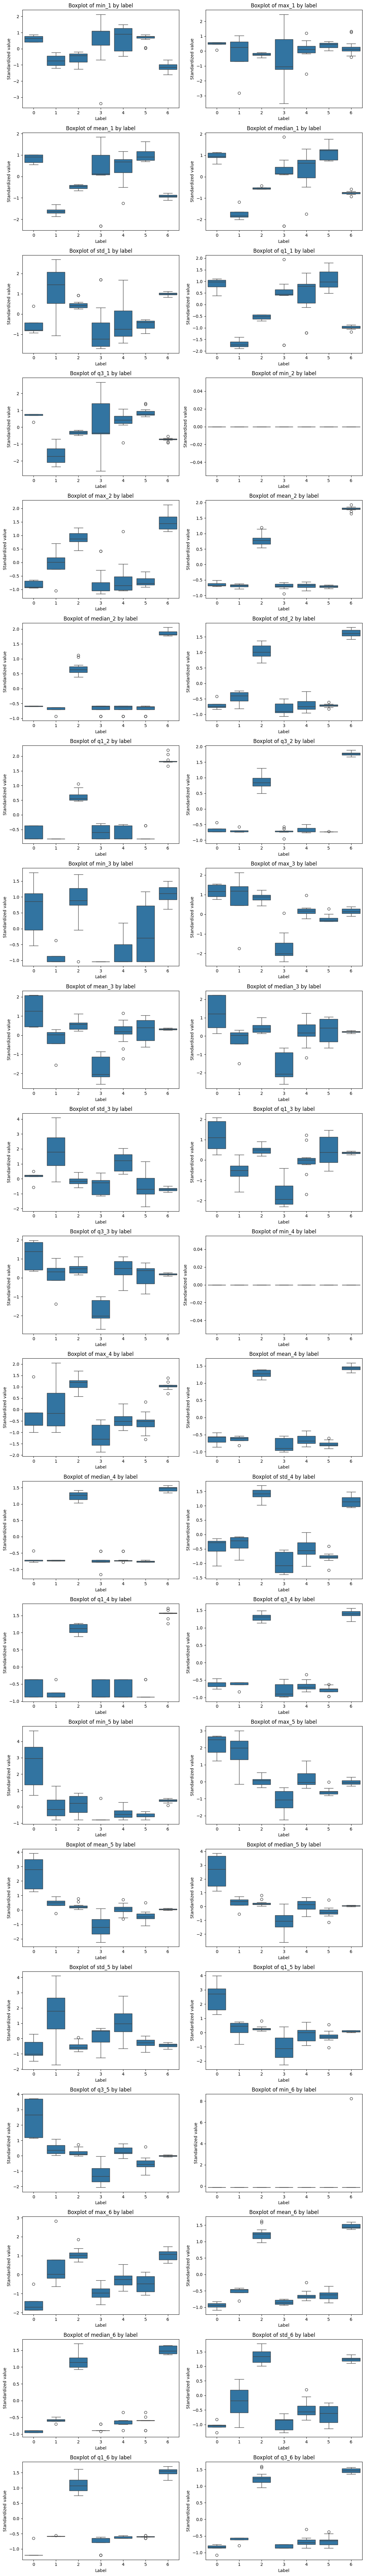

In [416]:
features = df_train_scaled.drop(columns='label').columns
label_col = 'label'

n_cols = 2
n_features = len(features)
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(12, 4 * n_rows))

for i, f in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=label_col, y=f, data=df_train_scaled)
    plt.title(f'Boxplot of {f} by label')
    plt.xlabel('Label')
    plt.ylabel('Standardized value')

plt.tight_layout()
plt.show()

Type
mean      368.170192
q3        350.436027
median    317.745043
q1        154.114553
std       109.167132
max        30.030112
min        14.638533
Name: F-Score, dtype: float64


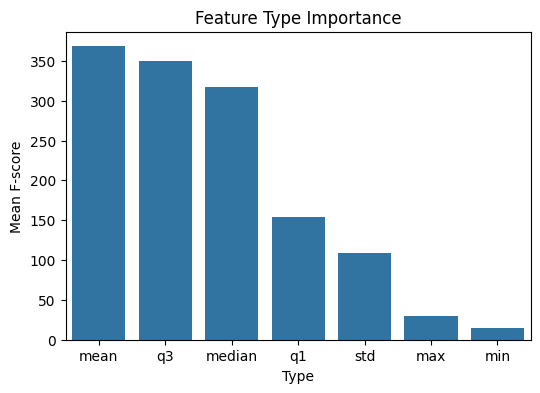

In [417]:
X = df_train_scaled.drop(columns='label')
y = df_train_scaled['label']

sel_var = VarianceThreshold(threshold=0.0)  # Remove features with 0 variance to avoid warning
X_nonconstant = pd.DataFrame(sel_var.fit_transform(X),
                             columns=X.columns[sel_var.get_support()])

# Select 3 most important features
selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X_nonconstant, y)

# Calculate F-score and p-value for each single feature
feature_scores = pd.DataFrame({
    'Feature': X_nonconstant.columns,   # Sample: mean_1
    'Type': X_nonconstant.columns.str.split('_').str[0],    # Sample: mean
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values(by='F-Score', ascending=False)

# Drop values with NaN F-score
feature_scores = feature_scores.dropna(subset=['F-Score'])

# Group features by their types
type_scores = feature_scores.groupby('Type')['F-Score'].mean().sort_values(ascending=False)
print(type_scores)

plt.figure(figsize=(6,4))
sns.barplot(x=type_scores.index, y=type_scores.values)
plt.ylabel("Mean F-score")
plt.title("Feature Type Importance")
plt.show()

As the graph indicates, **mean**, **q3** and **median** have the highest F-score among all the features. This means these 3 features have the most discriminative information for classification in the model. And the result is also aligned with what we see from the boxplot.

## 2. Time Series Classification Part 2: Binary and Multiclass Classification

### (a) Binary Classification Using Logistic Regression

#### i. Plots

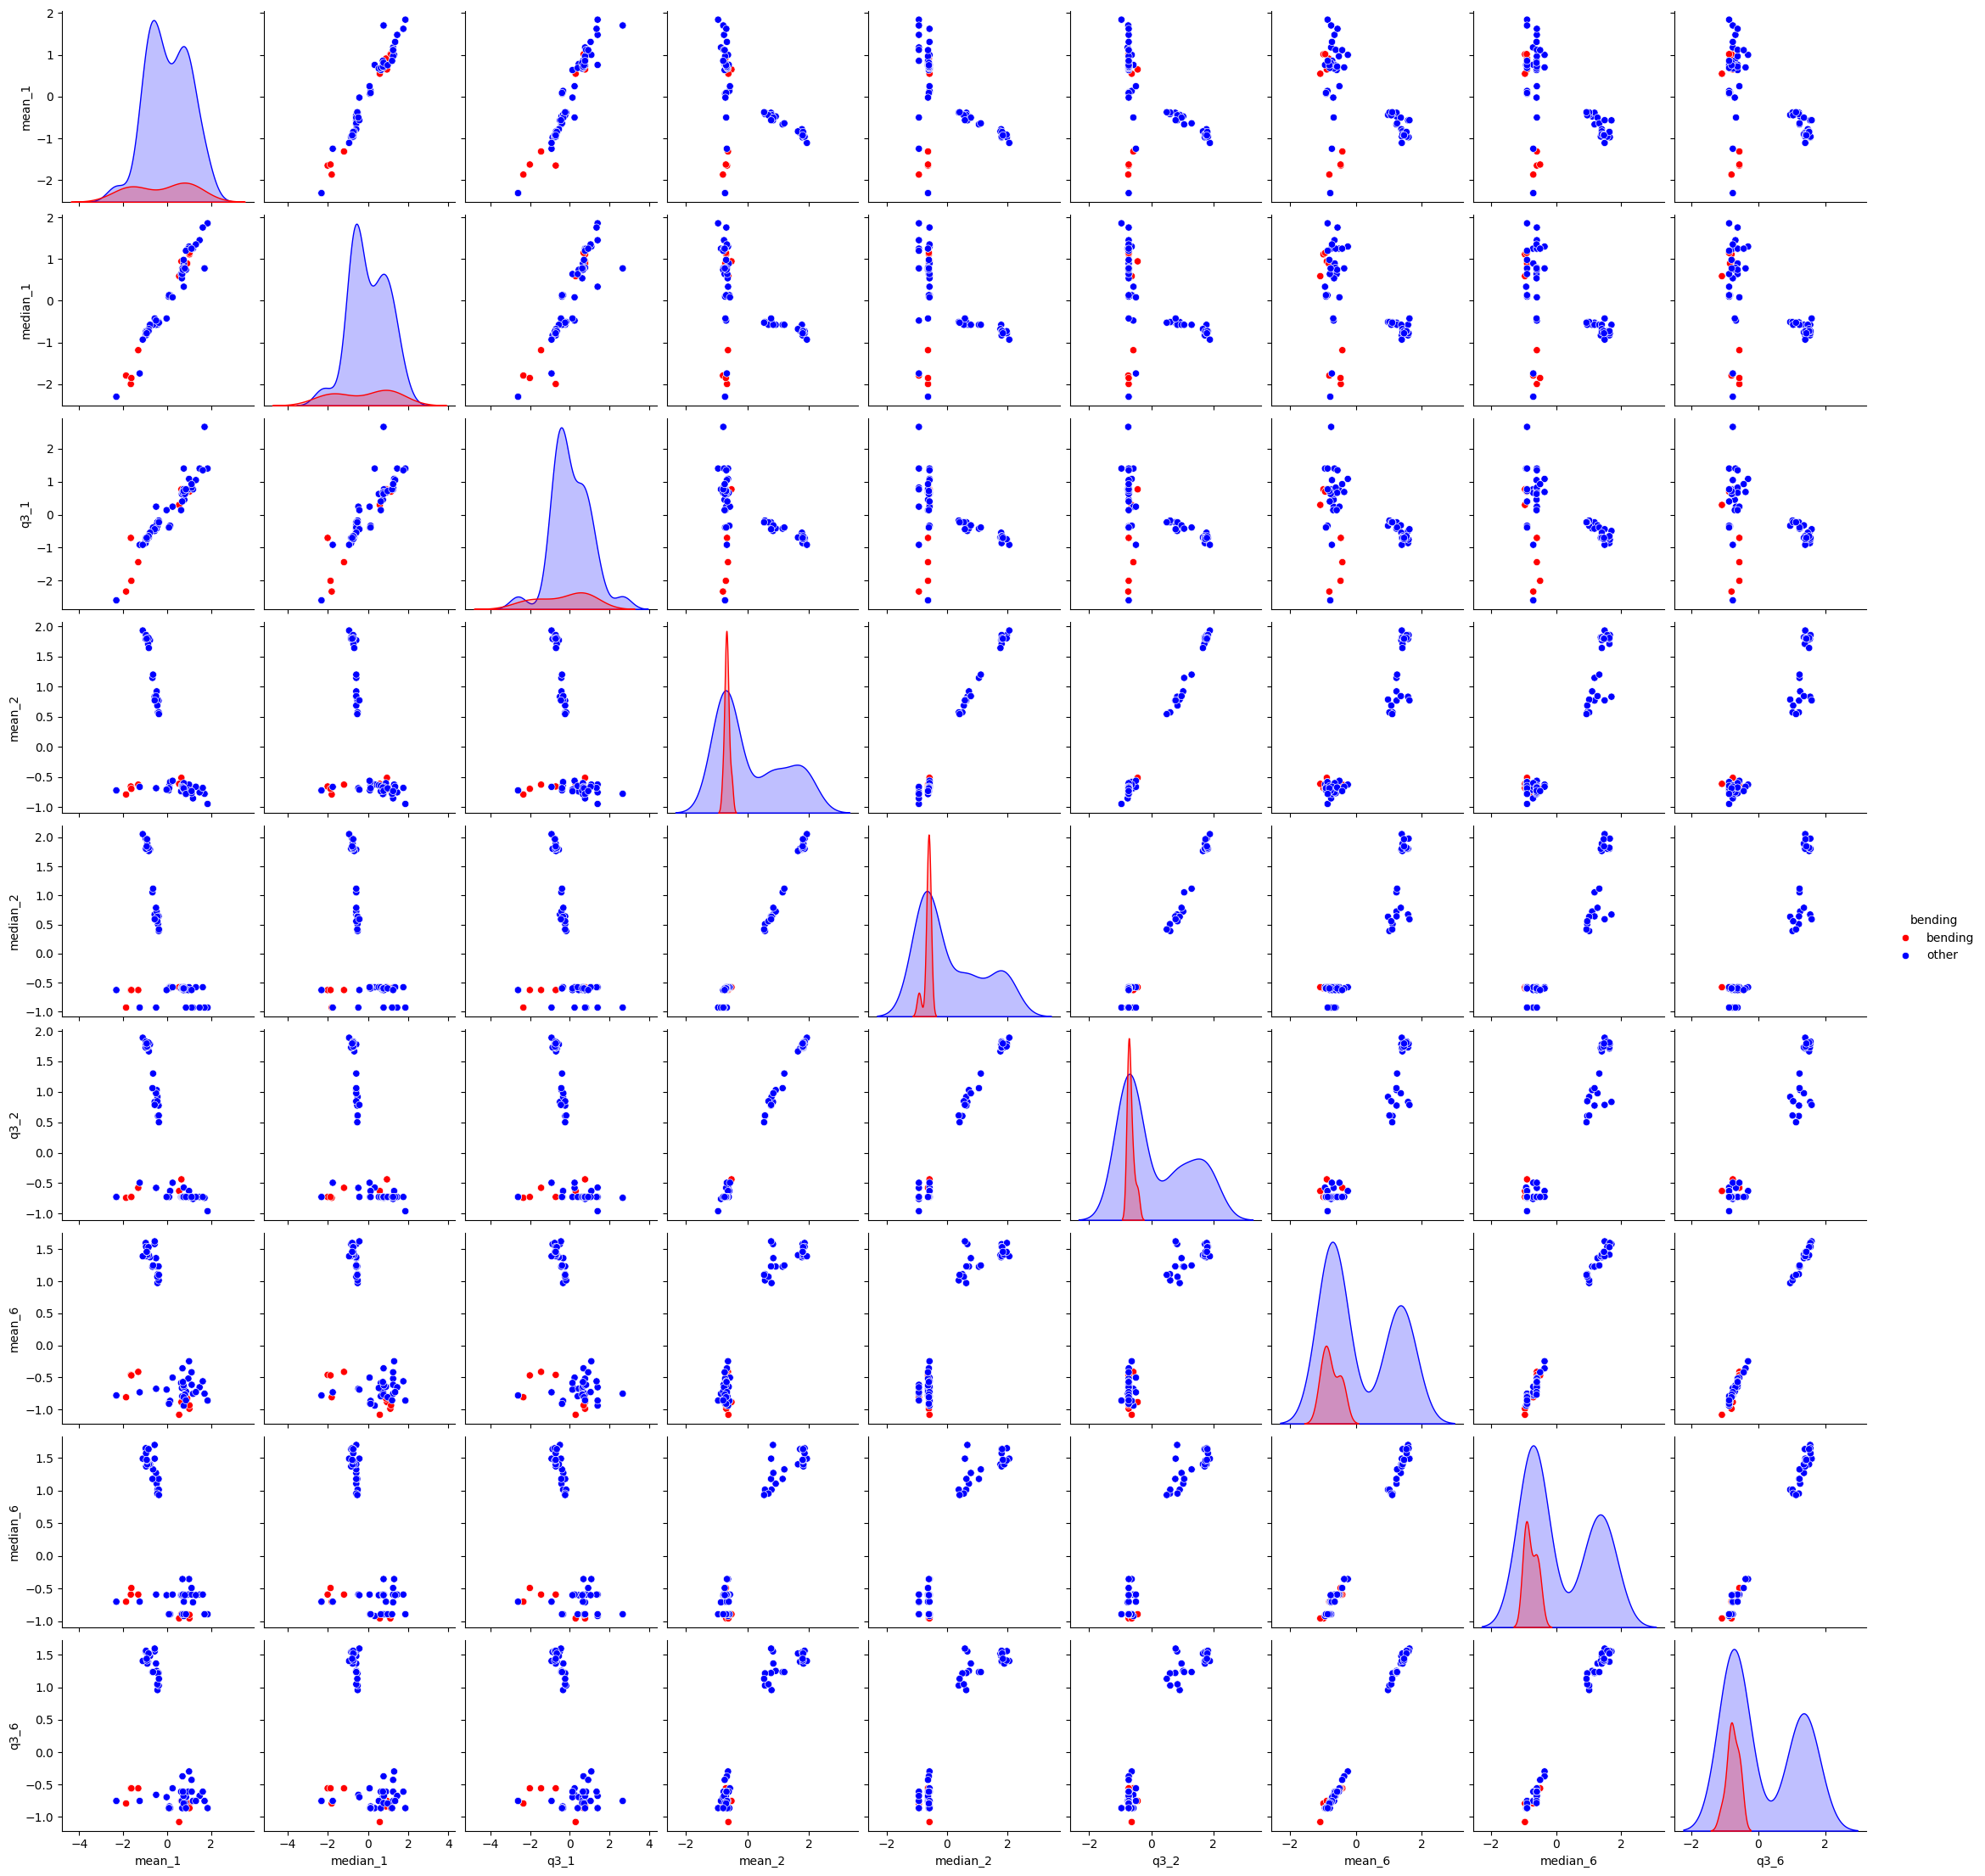

In [418]:
selected_features = [
    'mean_1', 'median_1', 'q3_1',
    'mean_2', 'median_2', 'q3_2',
    'mean_6', 'median_6', 'q3_6'
]

df_selected = df_train_scaled[selected_features].copy()
df_selected['label'] = y_train
df_selected['bending'] = df_selected['label'].apply(lambda x: 'bending' if x in [0,1] else 'other')

sns.pairplot(df_selected, 
             vars=selected_features, 
             hue='bending', 
             palette={'bending':'red','other':'blue'})
plt.show()

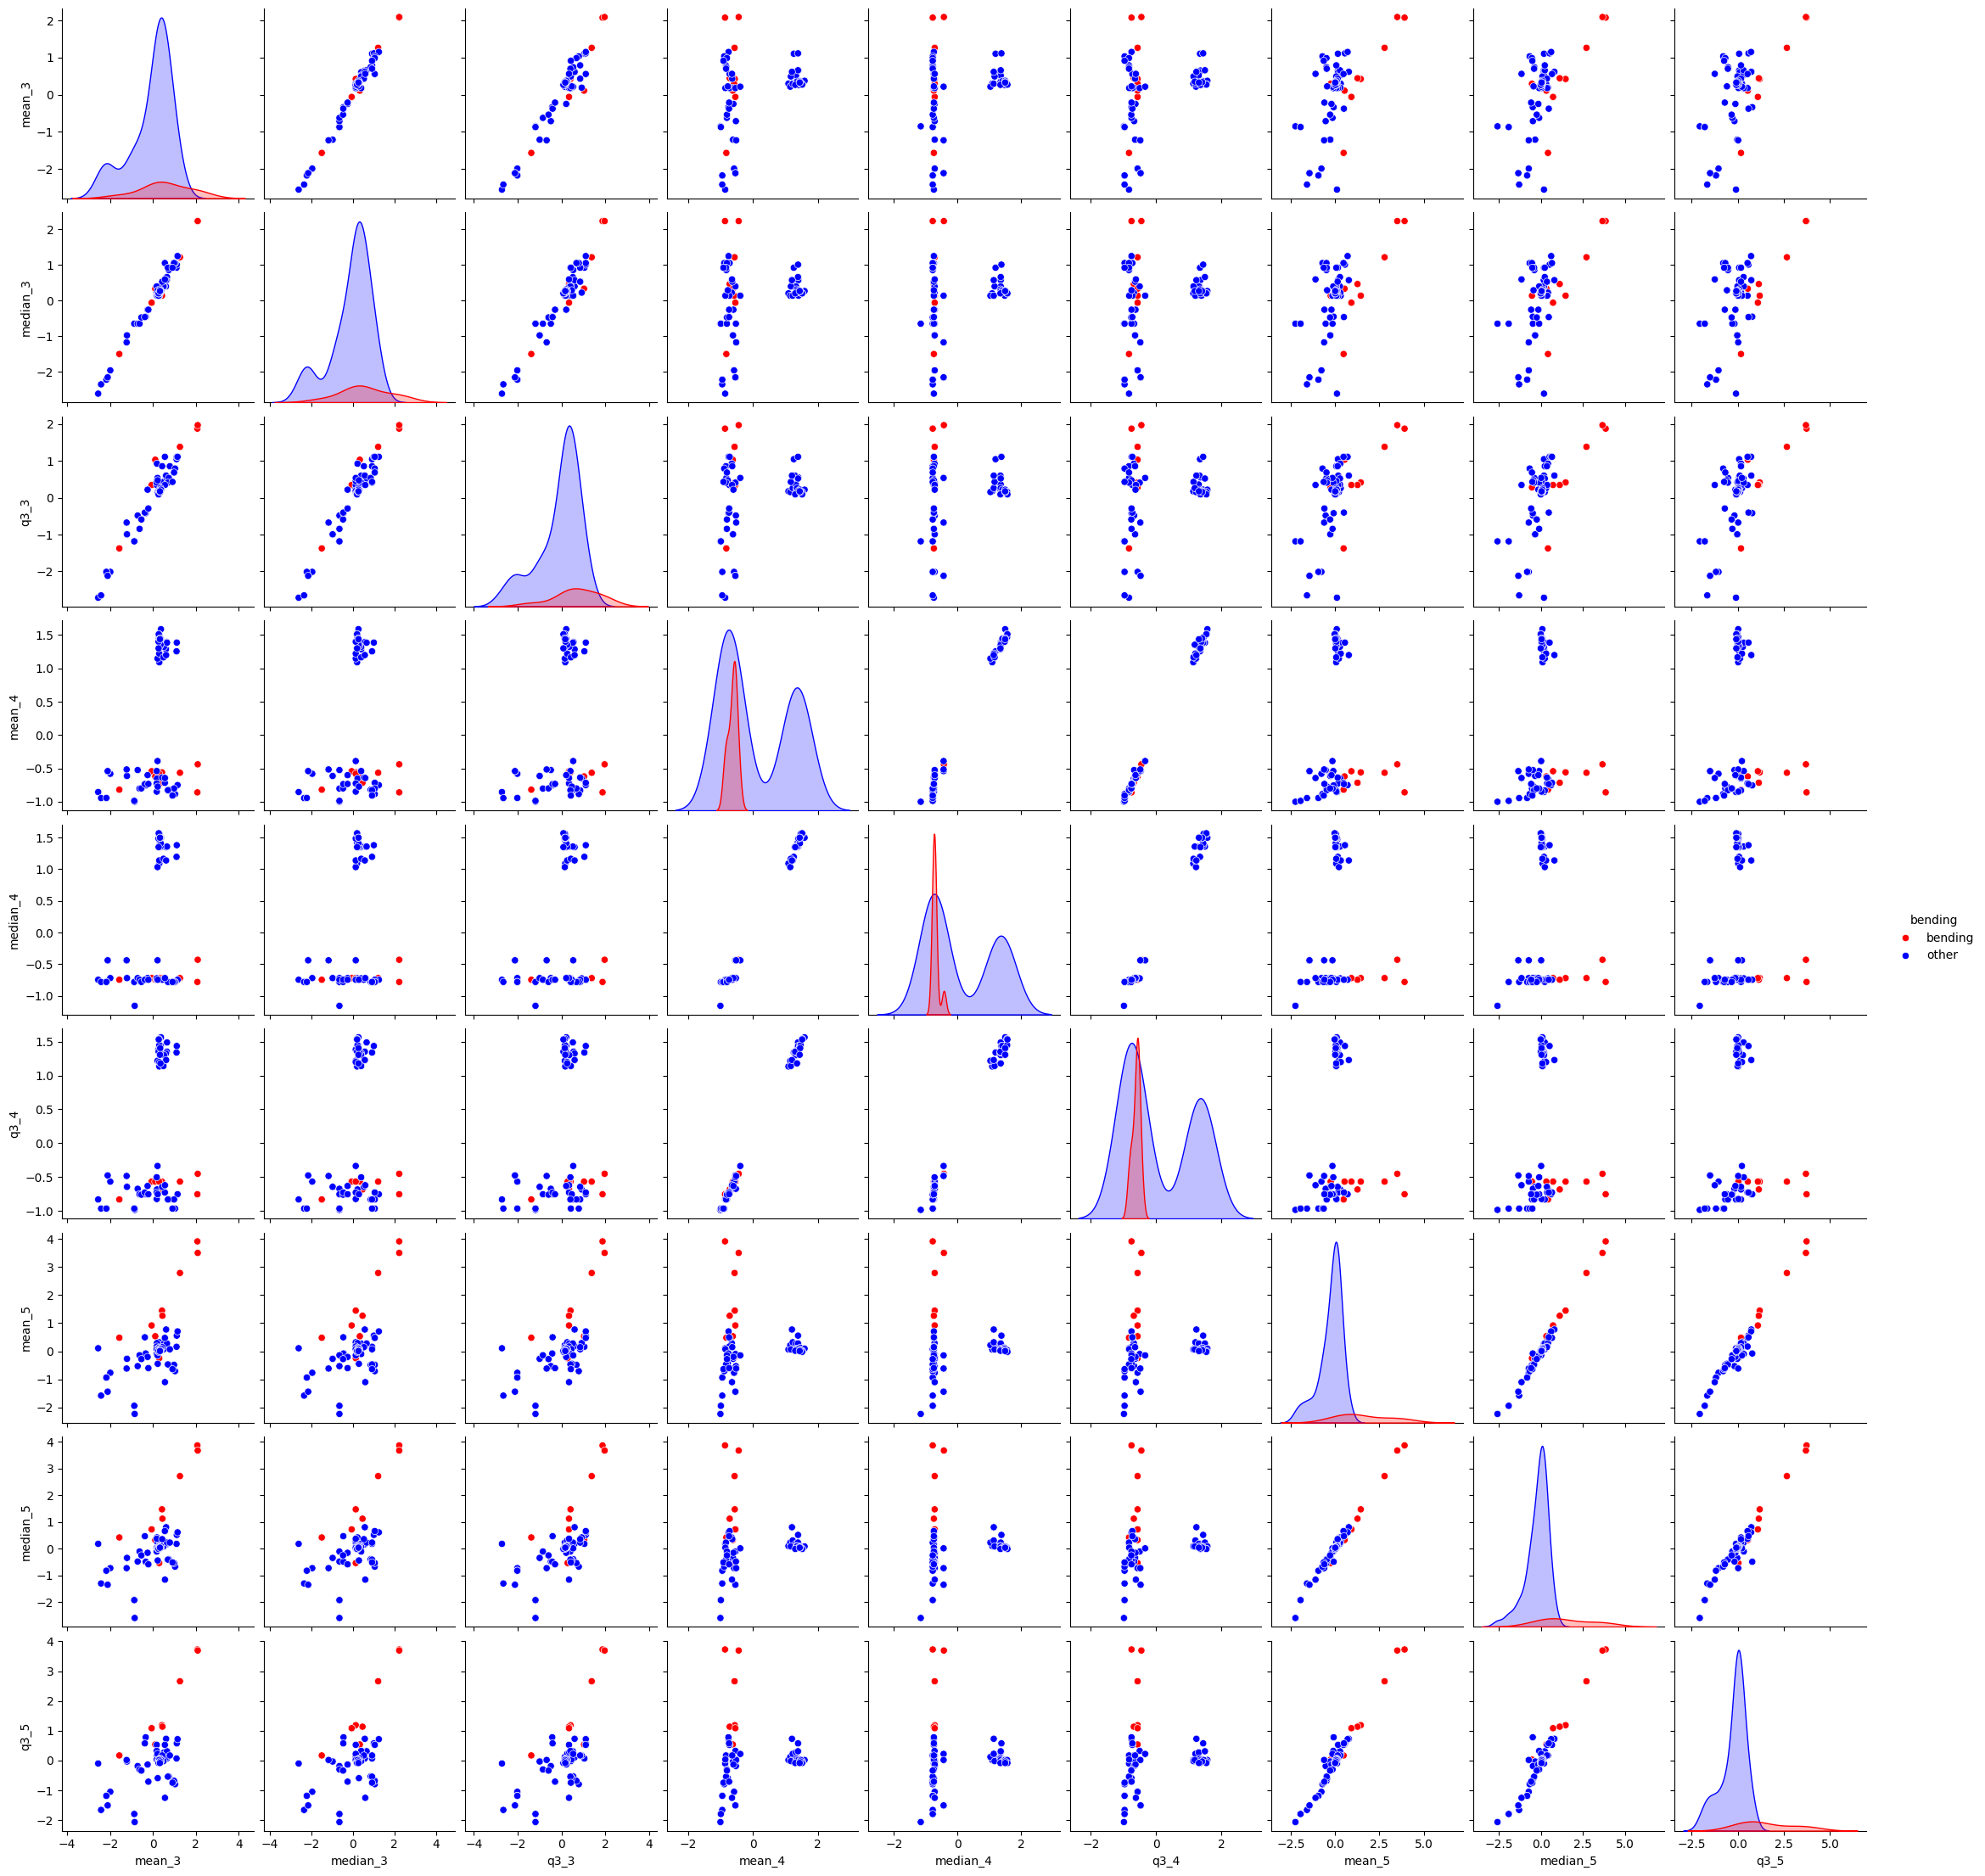

In [419]:
# Experiment using time series 3, 4, 5
selected_features_345 = [
    'mean_3', 'median_3', 'q3_3',
    'mean_4', 'median_4', 'q3_4',
    'mean_5', 'median_5', 'q3_5'
]

df_selected_345 = df_train_scaled[selected_features_345].copy()
df_selected_345['label'] = y_train
df_selected_345['bending'] = df_selected_345['label'].apply(lambda x: 'bending' if x in [0,1] else 'other')

sns.pairplot(
    df_selected_345, 
    vars=selected_features_345, 
    hue='bending', 
    palette={'bending':'red','other':'blue'}
)
plt.show()


#### ii. Splitted Plots

- Step1: Split X_train(raw data) into two halves based on time series

- Step2: Create a new dataframe called df_train_split to store the data, calculate mean, median, q3 for the 69 samples, each of them has 2 halves. The column names will be mean_1_a, median_1_a, q3_1_a, mean_1_b, median_1_b, q3_1_b, mean_2_a, median_2_a, q3_2_a, mean_2_b, median_2_b, q3_2_b,...

    The size will be 69 rows * 18 columns.(69 samples, 3 features * 3 time series * 2 splits)

    Note that split the data does not affect the original labels, so there is no need to adjust y_train.

- Step3: Create a new dataframe called df_train_split_scaled to standarize the information

- Step4: Create pairplot

In [420]:
def split_and_extract_features(df, ts_indices=[0,1,5]):

    cols = df.columns[1:]  # ignore 'time'
    extracted = []

    for idx in ts_indices:
        data = df[cols[idx]].dropna()
        mid = len(data) // 2
        part_a = data.iloc[:mid]
        part_b = data.iloc[mid:]
        
        # Extract features for part A
        extracted.extend([part_a.mean(), part_a.median(), np.percentile(part_a, 75)])
        # Extract features for part B
        extracted.extend([part_b.mean(), part_b.median(), np.percentile(part_b, 75)])
    
    return extracted

In [421]:
X_train_split_features = np.array([split_and_extract_features(df) for df in X_train])

# Create column names
cols_split = []
for ts in [1, 2, 6]:
    for f in ['mean','median','q3']:
        cols_split.append(f"{f}_{ts}_a")
    for f in ['mean','median','q3']:
        cols_split.append(f"{f}_{ts}_b")

# Build dataframe
df_train_split = pd.DataFrame(X_train_split_features, columns=cols_split)
df_train_split['label'] = y_train

print("Split feature dataframe shape:", df_train_split.shape)
df_train_split.head()

Split feature dataframe shape: (69, 19)


,mean_1_a,median_1_a,q3_1_a,mean_1_b,median_1_b,q3_1_b,mean_2_a,median_2_a,q3_2_a,mean_2_b,median_2_b,q3_2_b,mean_6_a,median_6_a,q3_6_a,mean_6_b,median_6_b,q3_6_b,label
0,44.057167,44.50,45.00,43.851833,43.50,45.00,0.381042,0.470,0.50,0.471458,0.5,0.5000,0.598250,0.500,1.00,0.388333,0.00,0.71,0
1,43.278875,45.00,45.25,41.080750,42.00,44.50,0.673292,0.485,1.00,0.718792,0.5,1.2275,0.640958,0.765,1.22,0.586083,0.47,0.87,0
2,41.621208,42.33,44.25,41.734917,41.50,42.00,0.623083,0.500,0.83,0.448875,0.5,0.5000,0.419083,0.430,0.71,0.347500,0.43,0.50,0
3,44.117042,45.00,45.00,42.792875,42.67,43.00,0.250042,0.000,0.50,0.506125,0.5,0.5000,0.815417,0.710,1.12,0.543875,0.50,0.71,0
4,43.486208,43.71,44.50,44.452042,44.50,44.75,0.378667,0.470,0.50,0.447583,0.5,0.5000,0.524875,0.470,0.83,0.585750,0.50,0.83,0


In [422]:
scaler = StandardScaler()
X_train_split_scaled = scaler.fit_transform(df_train_split.drop(columns=['label']))
df_train_split_scaled = pd.DataFrame(X_train_split_scaled, columns=cols_split)
df_train_split_scaled['label'] = y_train
df_train_split_scaled.head()

,mean_1_a,median_1_a,q3_1_a,mean_1_b,median_1_b,q3_1_b,mean_2_a,median_2_a,q3_2_a,mean_2_b,median_2_b,q3_2_b,mean_6_a,median_6_a,q3_6_a,mean_6_b,median_6_b,q3_6_b,label
0,1.049848,1.018302,0.971610,0.921696,0.767664,0.837410,-0.707550,-0.602820,-0.716662,-0.653259,-0.578573,-0.717197,-0.907299,-0.889988,-0.773026,-1.063165,-1.338715,-0.927471,0
1,0.890498,1.110810,1.031441,0.386304,0.498029,0.731761,-0.524692,-0.592446,-0.484624,-0.497454,-0.578573,-0.378542,-0.870458,-0.647986,-0.629572,-0.894925,-0.915262,-0.824057,0
2,0.551104,0.616816,0.792118,0.512694,0.408151,0.203513,-0.556107,-0.582071,-0.563517,-0.667485,-0.578573,-0.717197,-1.061852,-0.953913,-0.962124,-1.097905,-0.951300,-1.063202,0
3,1.062106,1.110810,0.971610,0.717098,0.618466,0.414812,-0.789516,-0.927886,-0.716662,-0.631421,-0.578573,-0.717197,-0.719966,-0.698213,-0.694778,-0.930835,-0.888233,-0.927471,0
4,0.932948,0.872138,0.851949,1.037660,0.947420,0.784585,-0.709036,-0.602820,-0.716662,-0.668298,-0.578573,-0.717197,-0.970594,-0.917384,-0.883876,-0.895209,-0.888233,-0.849910,0


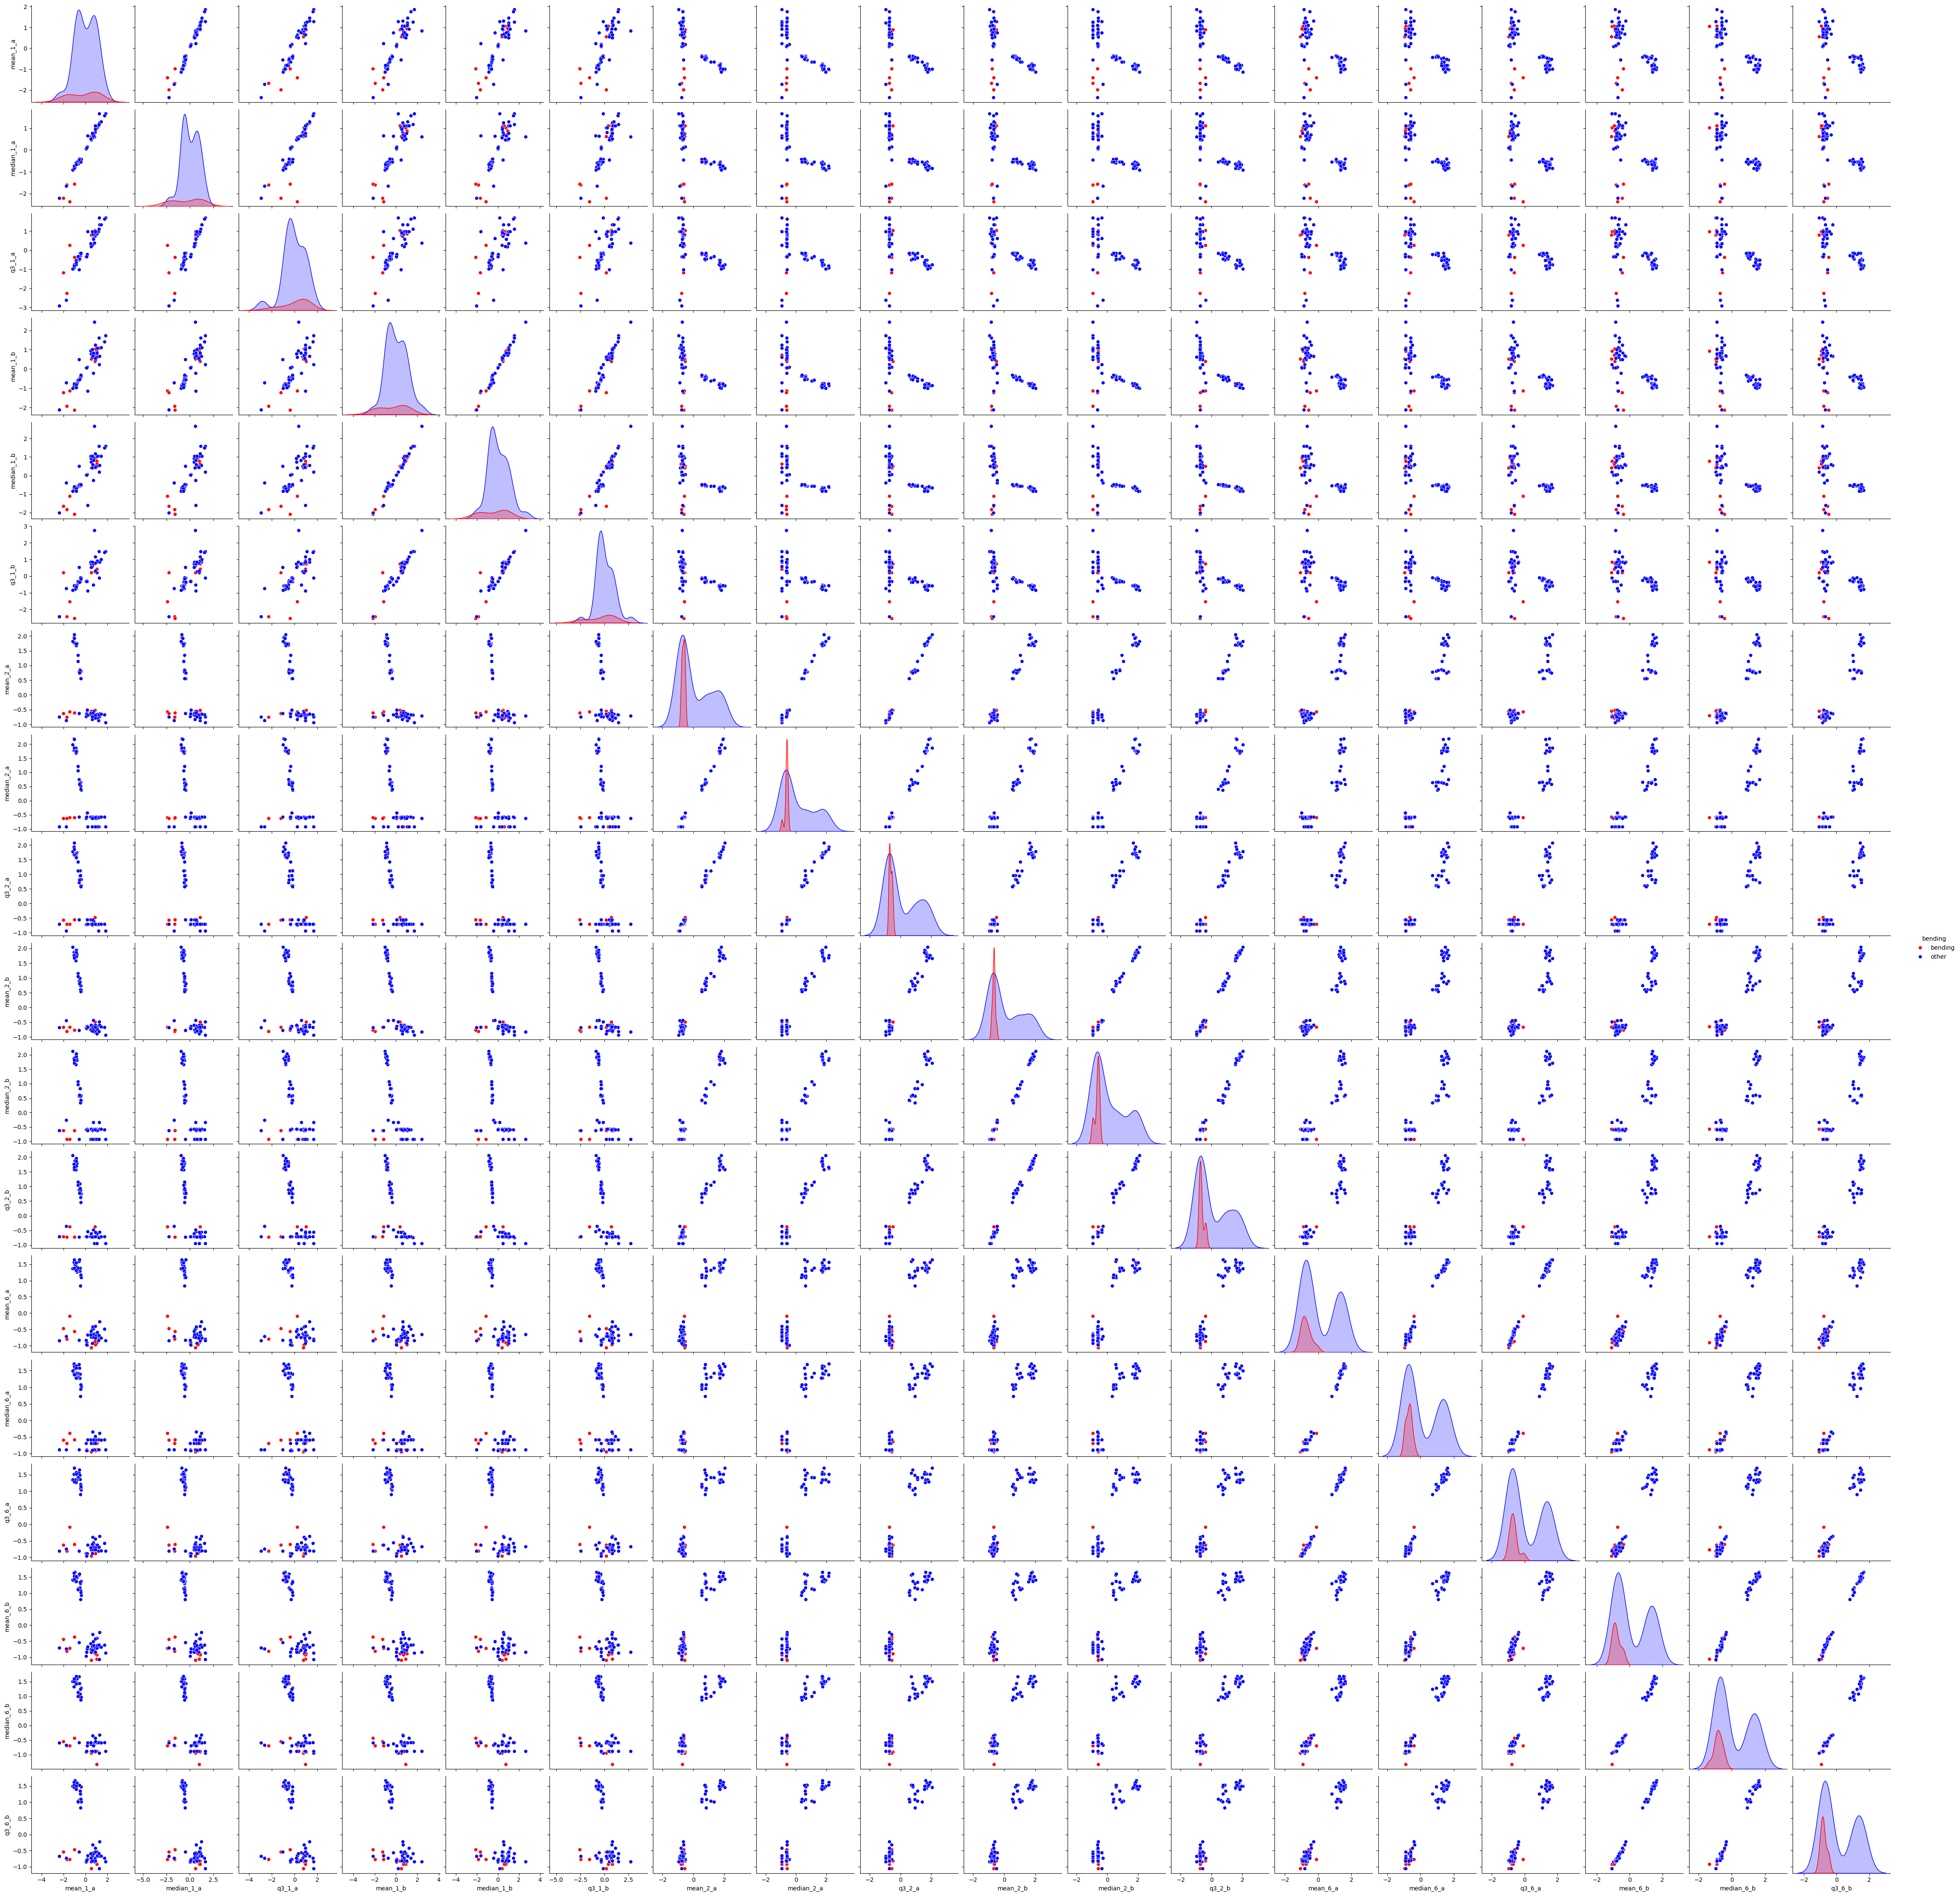

In [423]:
# Combine bending1 and bending2 as one label called "bending" and all the others called "other"
df_train_split_scaled['bending'] = df_train_split_scaled['label'].apply(lambda x: 'bending' if x in [0,1] else 'other')

sns.pairplot(df_train_split_scaled.drop(columns="label"), 
             hue="bending", 
             palette={'bending':'red','other':'blue'})
plt.show()

Compare the two plots, the one from (a)-i is the pairplots of the original time series features, the one from (a)-ii is the pairplots of the split time series features, there are no substantial difference between them. The patterns are mainly similar.

Maybe it is because all the features we extracted(mean, median, q3) are reflecting the overall distribution of the data, splitting the time series into two halves will not change these summary properties too much.

#### iii. Time Series Segments

- Step1: Loop over l from 1 to 20 to create the corresponding dataframes
    The size of dataframe will be 69 rows * (7 features * 6 time series * l) columns
- Step2: inside the loop, perform RFE and backward selection
    - apply RFE to select top p features, fitting logistic regression model
    - perform cross validation along with RFE
- Result: find optimal (l\*, p\*), the p with best cross validation result

Note: It is right way to do cross validation inside recursive feature elimination. If we perform RFE first, and select the optimal p features, then do the cross validation, it will cause information leakage because we use the data to fit the model and validate using the same data. Instead, we need to perform the feature selection inside each fold. Inside each fold, we fit RFE on the training data, and evaluate it using the validation fold. In this way, we can get an unbiased estimation.

In [424]:
def get_feature_matrix_for_l(X_df_list, l):
    
    all_instance_features = []
    
    for instance_df in X_df_list:
        
        # ts_data shape: (480, 6)
        ts_data = instance_df.iloc[:, 1:7].values   # ignore "time"
        
        segments = np.array_split(ts_data, l, axis=0)
        
        instance_features_for_l = []
        for segment in segments:
            # segment shape: (480/l, 6)
            seg_stats = [
                np.min(segment, axis=0), 
                np.max(segment, axis=0), 
                np.mean(segment, axis=0), 
                np.median(segment, axis=0), 
                np.std(segment, axis=0), 
                np.percentile(segment, 25, axis=0), 
                np.percentile(segment, 75, axis=0) 
            ]
            # transfer seg_stats to one-row flat shape
            flat_stats = np.array(seg_stats).ravel(order='C')
            instance_features_for_l.append(flat_stats)
        
        # Final vector shape: (6 * 7 * l,)
        all_instance_features.append(np.concatenate(instance_features_for_l))
        
    # final matrix: (69, 6 * 7 * l)
    return np.array(all_instance_features)

In [425]:
# transfer y_train from multi-class label to binary class label
# 1 means "bending" and 0 means "other"
y_binary_train = np.array([1 if y in [0, 1] else 0 for y in y_train])

# set the budget C → inf, max_iter to 5000(a higher value to avoid convergence warning)
logistic_model = LogisticRegression(C=1e11, max_iter=5000, solver='lbfgs', random_state=11)

# use 5-fold cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)

results = []

for l in range(1,21):
    X_L = get_feature_matrix_for_l(X_train, l)
    
    print(f"\n=== L = {l} ===")
    print(f"Feature matrix shape: {X_L.shape}")
    
    scaler = StandardScaler()
    X_L_scaled = scaler.fit_transform(X_L)
    
    # run RFE inside the 5-fold cross validation to find optimal p under current l
    rfecv = RFECV(
        estimator=logistic_model, 
        cv=cv_strategy, 
        scoring='accuracy'
    )
    
    rfecv.fit(X_L_scaled, y_binary_train)
    optimal_p_for_l = rfecv.n_features_
    max_acc_for_l = np.max(rfecv.cv_results_['mean_test_score'])
    
    print(f"Optimal P = {optimal_p_for_l}, CV Accuracy = {max_acc_for_l:.4f}")
    
    results.append({
        'l': l,
        'p': optimal_p_for_l,
        'cv_accuracy': max_acc_for_l,
        'total_features': X_L.shape[1]
    })


=== L = 1 ===
Feature matrix shape: (69, 42)
Optimal P = 26, CV Accuracy = 0.9714

=== L = 2 ===
Feature matrix shape: (69, 84)
Optimal P = 4, CV Accuracy = 0.9857

=== L = 3 ===
Feature matrix shape: (69, 126)
Optimal P = 5, CV Accuracy = 0.9714

=== L = 4 ===
Feature matrix shape: (69, 168)
Optimal P = 8, CV Accuracy = 1.0000

=== L = 5 ===
Feature matrix shape: (69, 210)
Optimal P = 8, CV Accuracy = 0.9429

=== L = 6 ===
Feature matrix shape: (69, 252)
Optimal P = 11, CV Accuracy = 0.9714

=== L = 7 ===
Feature matrix shape: (69, 294)
Optimal P = 10, CV Accuracy = 0.9714

=== L = 8 ===
Feature matrix shape: (69, 336)
Optimal P = 7, CV Accuracy = 0.9571

=== L = 9 ===
Feature matrix shape: (69, 378)
Optimal P = 6, CV Accuracy = 0.9429

=== L = 10 ===
Feature matrix shape: (69, 420)
Optimal P = 10, CV Accuracy = 0.9571

=== L = 11 ===
Feature matrix shape: (69, 462)
Optimal P = 5, CV Accuracy = 0.9714

=== L = 12 ===
Feature matrix shape: (69, 504)
Optimal P = 3, CV Accuracy = 1.0000

In [426]:
print("Optimal (l, p) combinations sorted by Cross-Validation Accuracy (descending): \n")

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(by='cv_accuracy', ascending=False)
print(summary_df.to_string(index=False, float_format="%.4f"))

Optimal (l, p) combinations sorted by Cross-Validation Accuracy (descending): 

 l  p  cv_accuracy  total_features
 4  8       1.0000             168
12  3       1.0000             504
20  1       0.9857             840
 2  4       0.9857              84
19 12       0.9857             798
14  2       0.9857             588
13  6       0.9857             546
18  1       0.9714             756
16  9       0.9714             672
 1 26       0.9714              42
 7 10       0.9714             294
 6 11       0.9714             252
 3  5       0.9714             126
11  5       0.9714             462
17 13       0.9703             714
10 10       0.9571             420
 8  7       0.9571             336
15 12       0.9571             630
 9  6       0.9429             378
 5  8       0.9429             210


From the summary table above, we can tell, the optimal (l\*, p\*) is (4, 8) and (12, 3) where their accuracy value is 1.0000.

#### iv. Confusion Matrix

- Step1: use optimal (l\*, p\*), train the final logistic regression model
- Step2: generate confusion matrix, ROC and AUC
- Step3: report βi's and calculate corresponding p-values

Note that we have two optimal combinations, (4, 8) and (12, 3) from the result of 2(a)iii. Based on the Principle of Parsimony, we will choose the model with less features. So here we will consider the case of (l\*, p\*) = (12, 3).

In [427]:
l_optimal = 12
p_optimal = 3

X_L_optimal = get_feature_matrix_for_l(X_train, l_optimal)

scaler = StandardScaler()
X_L_optimal_scaled = scaler.fit_transform(X_L_optimal)

# initialize the same model where the optimal (l, p) gives the highest accuracy
optimal_logistic_model = LogisticRegression(C=1e11, max_iter=5000, solver='lbfgs', random_state=11)

# create RFE model and select p_optimal attributes
rfe = RFE(estimator=logistic_model, n_features_to_select=p_optimal)

# fit rfe on the full standardized data
X_train_optimal_features = rfe.fit_transform(X_L_optimal_scaled, y_binary_train)    # shape: (69, 3)
optimal_model = rfe.estimator_

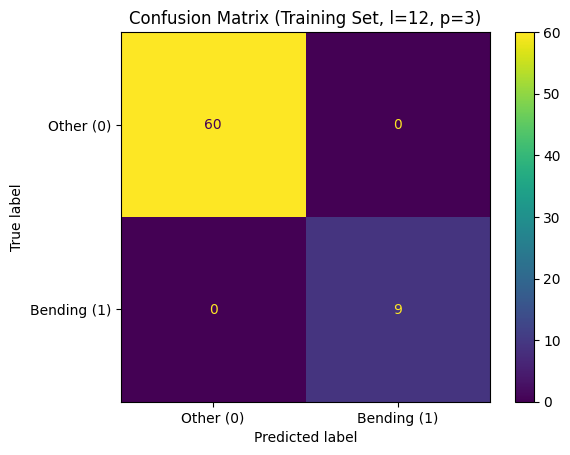

In [428]:
# ---Confusion matrix---
y_pred_train = optimal_model.predict(X_train_optimal_features)

cm = confusion_matrix(y_binary_train, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Other (0)', 'Bending (1)'])
disp.plot()
plt.title(f"Confusion Matrix (Training Set, l={l_optimal}, p={p_optimal})")
plt.show()

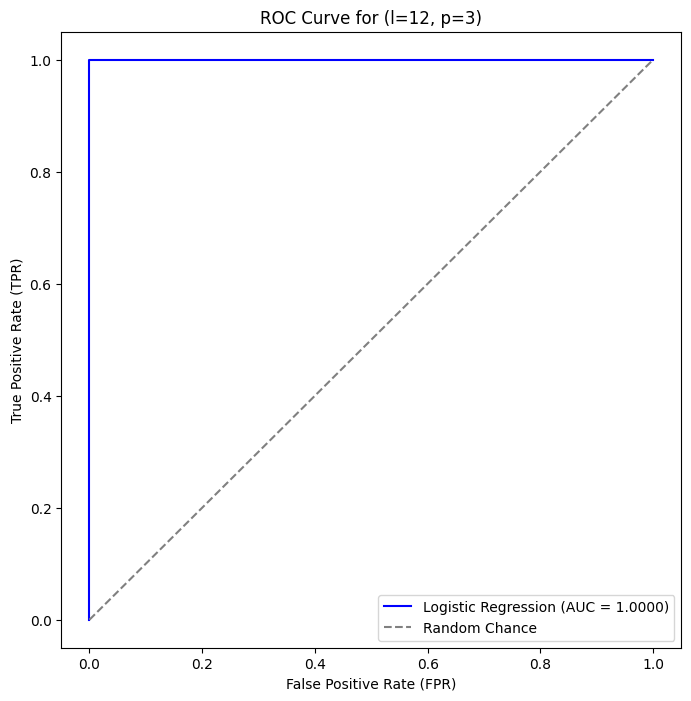

AUC Score: 1.0000


In [429]:
y_prob_train = optimal_model.predict_proba(X_train_optimal_features)[:, 1]

auc_score = roc_auc_score(y_binary_train, y_prob_train)
fpr, tpr, thresholds = roc_curve(y_binary_train, y_prob_train)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'ROC Curve for (l={l_optimal}, p={p_optimal})')
plt.legend(loc='lower right')
plt.show()

print(f"AUC Score: {auc_score:.4f}")

In [430]:
# ---Compute beta coefficients
selected_feature_indices = np.where(rfe.support_)[0]
print(f"Selected Feature Indices: {selected_feature_indices}")

# Print the intercept (Beta_0)
print(f"Intercept (Beta_0): {optimal_model.intercept_[0]:.4f}")

# Print the coefficients (Beta_i)
print("Coefficients (Beta_i):")
for i, coef in enumerate(optimal_model.coef_.ravel()):
    print(f"  Beta for Feature Index {selected_feature_indices[i]}: {coef:.4f}")

Selected Feature Indices: [ 10  76 258]
Intercept (Beta_0): -22.2035
Coefficients (Beta_i):
  Beta for Feature Index 10: 8.1181
  Beta for Feature Index 76: 11.0964
  Beta for Feature Index 258: -8.3834


In [431]:
# ---Compute p-values---
X_train_final_with_const = sm.add_constant(X_train_optimal_features)
logit_model = sm.Logit(y_binary_train, X_train_final_with_const)
logit_result = logit_model.fit(method='lbfgs')

print(logit_result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   69
Model:                          Logit   Df Residuals:                       65
Method:                           MLE   Df Model:                            3
Date:                Mon, 20 Oct 2025   Pseudo R-squ.:                  0.9999
Time:                        23:49:37   Log-Likelihood:             -0.0020120
converged:                       True   LL-Null:                       -26.718
Covariance Type:            nonrobust   LLR p-value:                 1.484e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -31.2783    101.126     -0.309      0.757    -229.482     166.926
x1            11.2712     82.969      0.136      0.892    -151.345     173.887
x2            15.3919     86.516      0.178      0.8

#### v. Test Classifier

Test feature matrix shape: (19, 504)
Final test feature shape: (19, 3)
Test Set Accuracy: 0.9474


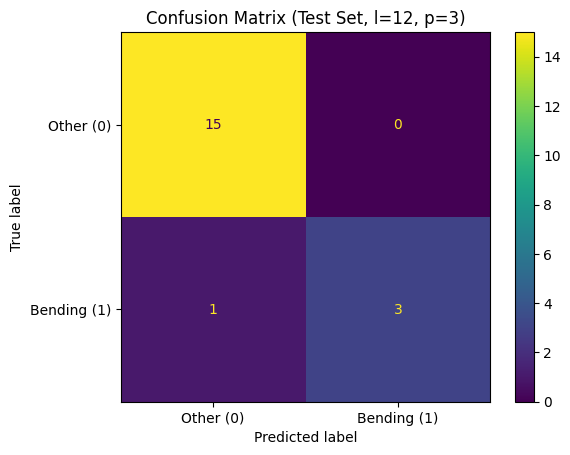

In [432]:
y_binary_test = np.array([1 if y in [0, 1] else 0 for y in y_test])

# optimal l = 12
# break the test set into 12 segments
X_L_test = get_feature_matrix_for_l(X_test, l_optimal)
print(f"Test feature matrix shape: {X_L_test.shape}")

X_L_test_scaled = scaler.transform(X_L_test)

# optimal p = 3
X_test_final_features = rfe.transform(X_L_test_scaled)
print(f"Final test feature shape: {X_test_final_features.shape}")

# predict test data using optimal model
y_pred_test = optimal_model.predict(X_test_final_features)

test_accuracy = accuracy_score(y_binary_test, y_pred_test)

cv_accuracy = summary_df.iloc[0]['cv_accuracy']
print(f"Test Set Accuracy: {test_accuracy:.4f}")

# generate confusion matrix for test data for comparison
cm_test = confusion_matrix(y_binary_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Other (0)', 'Bending (1)'])
disp_test.plot()
plt.title(f"Confusion Matrix (Test Set, l={l_optimal}, p={p_optimal})")
plt.show()

From the result we can see the accuracy drops from 1.0000 in training data to 0.9474 in the test data. It reflects the real performance of the model, and also indicates that the model is over-fitting in the training data.

#### vi. Separation

Yes, the classes seem to be well-separated.

From the logit regression result table generated in 2(a)iv, the statsmodel warning says that "Possibly complete quasi-separation: A fraction 0.96 of observations can be
perfectly predicted. This might indicate that there is complete quasi-separation. In this case some parameters will not be identified."

And we can see from the results of 2(a)iv that the coefficients of betas are large, and the standard errors of these coefficients are also very large.

All these signs suggest that the classes are complete separated, which will cause instability in the logistic regression calculations.

#### vii. Imbalance

Yes, from the confusion matrix of training set, we can see a strong imbalance pattern among classes. There are 9 samples of bending, and 60 samples of others.

- Step1: resample from others dataset to generate balanced training set
- Step2: build logistic regression model using same parameter as optimal model in 2(a)iv
- Step3: adjust the parameter of the balanced model
    
    Because the balanced model is based on a biased dataset that does not reflect reality, we need to adjust the intercept and coefficients based on the weights of features. If we don't adjust, the model will consider the chance of "bending" and "other" are 50/50. The prediction result will be wrong.
- Step4: use the adjusted balanced model to predict result
- Step5: generate cm, ROC and AUC of the model

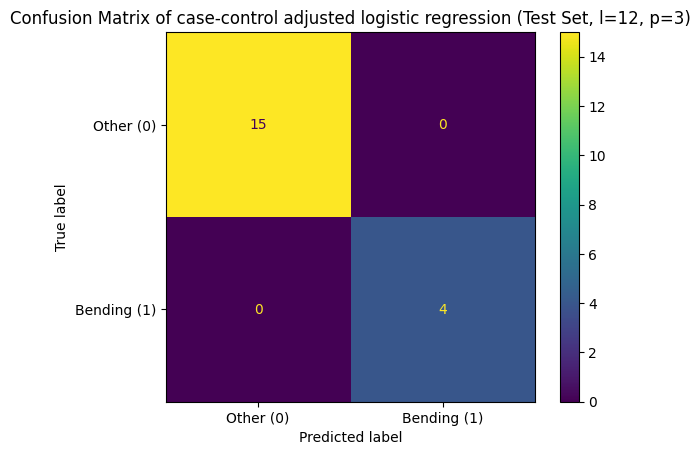

AUC (case-control adjusted): 1.0


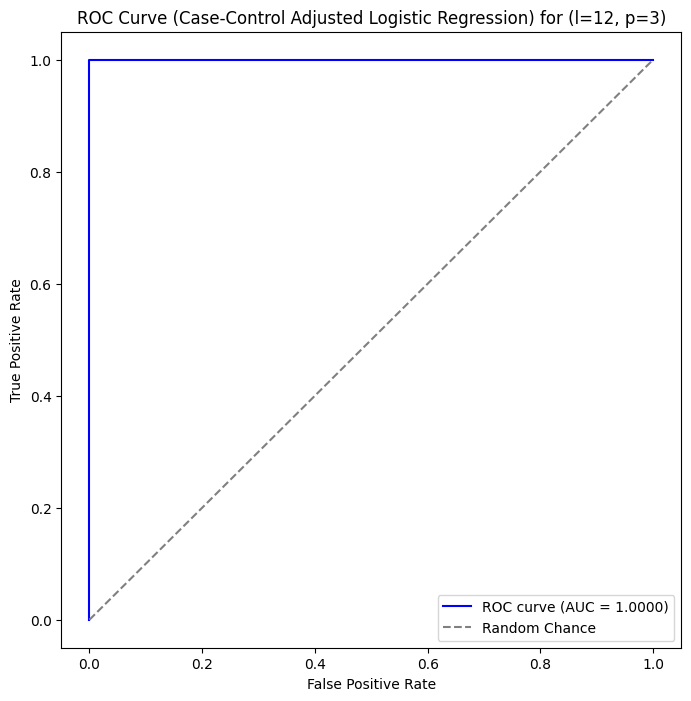

In [433]:
# ---case-control sampling---

# cases of bending
bending_indices = np.where(y_binary_train == 1)[0]      # size: 9
# cases of other
other_indices = np.where(y_binary_train == 0)[0]        # size: 60

# sampling cases from others to match the size of bending
n_cases = len(bending_indices)
sampled_other_indices = np.random.choice(other_indices, size=n_cases, replace=False)        # size: 9

balanced_indices = np.concatenate([bending_indices, sampled_other_indices])     # size: 9+9


# ---build logistic regression model---
X_balanced = X_train_optimal_features[balanced_indices]
y_balanced = y_binary_train[balanced_indices]

model_balanced = LogisticRegression(C=1e11, max_iter=5000, solver='lbfgs', random_state=11)
model_balanced.fit(X_balanced, y_balanced)


# ---adjust parameters---
# real ratio
pi_1 = n_cases / len(y_binary_train)                    # 9 / 69
pi_0 = len(other_indices) / len(y_binary_train)         # 60 / 69

# sample ratio
pi_1_balanced = n_cases / len(y_balanced)               # 9 / 18 = 0.5
pi_0_balanced = n_cases / len(y_balanced)               # 9 / 18 = 0.5

# calculate adjustment factor
log_odds_adjustment = np.log( (pi_1 / pi_0) / (pi_1_balanced / pi_0_balanced) )


# ---apply adjustment to the model---
log_odds_test = model_balanced.decision_function(X_test_final_features)
adjusted_log_odds_test = log_odds_test + log_odds_adjustment

# ---predict result using adjusted balanced model---
y_prob_balanced = expit(adjusted_log_odds_test)
y_pred_balanced = (y_prob_balanced > 0.5).astype(int)


# ---generate cm, roc and auc
cm_balanced = confusion_matrix(y_binary_test, y_pred_balanced)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=['Other (0)', 'Bending (1)'])
disp_test.plot()
plt.title(f"Confusion Matrix of case-control adjusted logistic regression (Test Set, l={l_optimal}, p={p_optimal})")
plt.show()

fpr, tpr, _ = roc_curve(y_binary_test, y_prob_balanced)
auc_balanced = roc_auc_score(y_binary_test, y_prob_balanced)
print("AUC (case-control adjusted):", auc_balanced)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_balanced:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (Case-Control Adjusted Logistic Regression) for (l={l_optimal}, p={p_optimal})')
plt.legend()
plt.show()


### (b) Binary Classification Using L1-penalized logistic regression

#### i. Time Series Segments

In [434]:
results_l1 = []
for l in range(1,21):

    X_L = get_feature_matrix_for_l(X_train, l)
    
    print(f"\n=== L = {l} ===")
    print(f"Feature matrix shape: {X_L.shape}")
    
    scaler = StandardScaler()
    X_L_scaled = scaler.fit_transform(X_L)
    
    l1_model_cv = LogisticRegressionCV(
        Cs=20, 
        cv=cv_strategy, 
        penalty='l1', 
        scoring="accuracy", 
        solver="liblinear", 
        max_iter=5000,
        random_state=11
    )
    
    l1_model_cv.fit(X_L_scaled, y_binary_train)
    
    mean_scores_per_c = np.mean(l1_model_cv.scores_[1], axis=0)
    best_acc_for_l = np.max(mean_scores_per_c)
    best_C_for_l = l1_model_cv.Cs_[np.argmax(mean_scores_per_c)]
    
    print(f"Best C = {best_C_for_l:.4f}, CV Accuracy = {best_acc_for_l:.4f}")
    
    results_l1.append({
        'l': l,
        'best_C': best_C_for_l,
        'cv_accuracy': best_acc_for_l,
        'total_features': X_L.shape[1]
    })


=== L = 1 ===
Feature matrix shape: (69, 42)
Best C = 78.4760, CV Accuracy = 0.9714

=== L = 2 ===
Feature matrix shape: (69, 84)
Best C = 4.2813, CV Accuracy = 0.9714

=== L = 3 ===
Feature matrix shape: (69, 126)
Best C = 78.4760, CV Accuracy = 0.9714

=== L = 4 ===
Feature matrix shape: (69, 168)
Best C = 545.5595, CV Accuracy = 0.9714

=== L = 5 ===
Feature matrix shape: (69, 210)
Best C = 78.4760, CV Accuracy = 0.9714

=== L = 6 ===
Feature matrix shape: (69, 252)
Best C = 78.4760, CV Accuracy = 0.9714

=== L = 7 ===
Feature matrix shape: (69, 294)
Best C = 29.7635, CV Accuracy = 0.9857

=== L = 8 ===
Feature matrix shape: (69, 336)
Best C = 29.7635, CV Accuracy = 0.9429

=== L = 9 ===
Feature matrix shape: (69, 378)
Best C = 3792.6902, CV Accuracy = 0.9571

=== L = 10 ===
Feature matrix shape: (69, 420)
Best C = 11.2884, CV Accuracy = 0.9714

=== L = 11 ===
Feature matrix shape: (69, 462)
Best C = 1.6238, CV Accuracy = 0.9857

=== L = 12 ===
Feature matrix shape: (69, 504)
Best 

In [435]:
print("Optimal (l, c) combinations sorted by Cross-Validation Accuracy (descending): \n")

summary_df_l1 = pd.DataFrame(results_l1)
summary_df_l1 = summary_df_l1.sort_values(by='cv_accuracy', ascending=False)
print(summary_df_l1.to_string(index=False, float_format="%.4f"))

Optimal (l, c) combinations sorted by Cross-Validation Accuracy (descending): 

 l    best_C  cv_accuracy  total_features
11    1.6238       0.9857             462
19    4.2813       0.9857             798
12    0.6158       0.9857             504
 7   29.7635       0.9857             294
10   11.2884       0.9714             420
18    0.6158       0.9714             756
 2    4.2813       0.9714              84
 1   78.4760       0.9714              42
 6   78.4760       0.9714             252
 5   78.4760       0.9714             210
 4  545.5595       0.9714             168
 3   78.4760       0.9714             126
20   29.7635       0.9714             840
13    0.6158       0.9703             546
 9 3792.6902       0.9571             378
16    4.2813       0.9571             672
17   78.4760       0.9571             714
15 3792.6902       0.9560             630
 8   29.7635       0.9429             336
14   29.7635       0.9429             588


From the summary table we can see that there are 4 pairs of (l, c) reached the highest accuracy 0.9857. Based on the principle of parsimony, when there is a tie, we will choose the model with less complexity. So here we will choose (l, c) = (12, 0.6158) as the optimal (l\*, c\*).

#### ii. Comparison

In [436]:
print(f"Using RFE model with optimal (l={l_optimal}, C={p_optimal})")
print(f"Best CV Accuracy: 1.0000")

X_train_final_with_const = sm.add_constant(X_train_optimal_features)
logit_model = sm.Logit(y_binary_train, X_train_final_with_const)
logit_result = logit_model.fit(method='lbfgs')

print(logit_result.summary())

Using RFE model with optimal (l=12, C=3)
Best CV Accuracy: 1.0000
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   69
Model:                          Logit   Df Residuals:                       65
Method:                           MLE   Df Model:                            3
Date:                Mon, 20 Oct 2025   Pseudo R-squ.:                  0.9999
Time:                        23:49:40   Log-Likelihood:             -0.0020120
converged:                       True   LL-Null:                       -26.718
Covariance Type:            nonrobust   LLR p-value:                 1.484e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -31.2783    101.126     -0.309      0.757    -229.482     166.926
x1            11.2712     82.969      0.136      0.892    -151.34

In [437]:
best_l_l1 = 12
best_C_l1 = 0.6158
print(f"Using L1 model with optimal (l={best_l_l1}, C={best_C_l1})")
print(f"Best CV Accuracy: 0.9857")

l1_selector_model = LogisticRegression(
    C=best_C_l1,
    penalty='l1',
    solver='liblinear',
    max_iter=5000,
    random_state=11
)
l1_selector_model.fit(X_L_optimal_scaled, y_binary_train)

coefs_l1 = l1_selector_model.coef_.ravel()
selected_indices_l1 = np.where(coefs_l1 != 0)[0]

print(f"L1 model selected {len(selected_indices_l1)} features.")

X_train_post_lasso = X_L_optimal_scaled[:, selected_indices_l1]
X_with_const = sm.add_constant(X_train_post_lasso)

logit_model_post_lasso = sm.Logit(y_binary_train, X_with_const)
logit_result_post_lasso = logit_model_post_lasso.fit(method='lbfgs', disp=0)

print(logit_result_post_lasso.summary())

Using L1 model with optimal (l=12, C=0.6158)
Best CV Accuracy: 0.9857
L1 model selected 7 features.
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   69
Model:                          Logit   Df Residuals:                       61
Method:                           MLE   Df Model:                            7
Date:                Mon, 20 Oct 2025   Pseudo R-squ.:                   1.000
Time:                        23:49:40   Log-Likelihood:            -0.00098112
converged:                       True   LL-Null:                       -26.718
Covariance Type:            nonrobust   LLR p-value:                 3.044e-09
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -14.9883     64.470     -0.232      0.816    -141.348     111.371
x1             5.3798    245.74

In terms of better accuracy in training set, RFE performs better than L1 model where it reaches 1.0000 accuracy. And since the optimal l of both models is 12, the RFE model chooses fewer features, it turns out RFE model gives a simplier model.

However, the results returned by both models are similar. Both of them have a warning of complete quasi-separation, which indicates that the features are perfectly separate the training data. This will cause instability in statistical calculations where we can see both of them have high p-values. Also, the perfect accuracy in training data reflects the over-fitting situation of both models.

From the perspective of implementing, L1-penalized method is easier to implement. Because we have encoded ``LogisticRegressionCV`` method to set up and fit the model. The package perform
cross-validation for λ automatically. And the running time of L1 model is less than RFE model.

### (c) Multi-class Classification (The Realistic Case)

#### i. Time Series Segments

- Step1: loop over l = 1,2,...20 to find optimal (l, c)
- Step2: use the optimal (l,c) to generate L1-penalized model and train
- Step3: predict data using the optimal model
    
    Note that here we are performing multi-class classification, we will use the y_train as the labels, i.e. label from 0 to 6 to represent 6 different movements.
- Step4: generate cm, ROC and AUC

In [438]:
results_multi = []

for l in range(1, 21):

    X_L = get_feature_matrix_for_l(X_train, l)
    
    print(f"\n=== L = {l} ===")
    print(f"Feature matrix shape: {X_L.shape}")
    
    scaler = StandardScaler()
    X_L_scaled = scaler.fit_transform(X_L)
    
    multi_model_cv = LogisticRegressionCV(
        Cs=20, 
        cv=cv_strategy, 
        penalty='l1', 
        scoring='accuracy', 
        solver='saga', 
        multi_class='multinomial', 
        max_iter=5000, 
        random_state=11
    )
    
    multi_model_cv.fit(X_L_scaled, y_train)
    
    scores_key = list(multi_model_cv.scores_.keys())[0]
    mean_scores_per_c = np.mean(multi_model_cv.scores_[scores_key], axis=0)
    
    best_acc_for_l = np.max(mean_scores_per_c)
    best_C_for_l = multi_model_cv.Cs_[np.argmax(mean_scores_per_c)]
    
    print(f"Best C = {best_C_for_l:.4f}, CV Accuracy = {best_acc_for_l:.4f}")
    
    results_multi.append({
        'l': l,
        'best_C': best_C_for_l,
        'cv_accuracy': best_acc_for_l
    })


=== L = 1 ===
Feature matrix shape: (69, 42)
Best C = 4.2813, CV Accuracy = 0.9000

=== L = 2 ===
Feature matrix shape: (69, 84)
Best C = 4.2813, CV Accuracy = 0.8846

=== L = 3 ===
Feature matrix shape: (69, 126)
Best C = 0.2336, CV Accuracy = 0.8703

=== L = 4 ===
Feature matrix shape: (69, 168)
Best C = 29.7635, CV Accuracy = 0.8703

=== L = 5 ===
Feature matrix shape: (69, 210)
Best C = 206.9138, CV Accuracy = 0.8407

=== L = 6 ===
Feature matrix shape: (69, 252)
Best C = 0.2336, CV Accuracy = 0.8110

=== L = 7 ===
Feature matrix shape: (69, 294)
Best C = 4.2813, CV Accuracy = 0.8538

=== L = 8 ===
Feature matrix shape: (69, 336)
Best C = 1.6238, CV Accuracy = 0.8110

=== L = 9 ===
Feature matrix shape: (69, 378)
Best C = 78.4760, CV Accuracy = 0.8549

=== L = 10 ===
Feature matrix shape: (69, 420)
Best C = 4.2813, CV Accuracy = 0.8121

=== L = 11 ===
Feature matrix shape: (69, 462)
Best C = 29.7635, CV Accuracy = 0.7824

=== L = 12 ===
Feature matrix shape: (69, 504)
Best C = 0.2

In [439]:
print("Optimal (l, c) combinations sorted by Cross-Validation Accuracy (descending): \n")

summary_df_multi = pd.DataFrame(results_multi)
summary_df_multi = summary_df_multi.sort_values(by='cv_accuracy', ascending=False)
print(summary_df_multi.to_string(index=False, float_format="%.4f"))

Optimal (l, c) combinations sorted by Cross-Validation Accuracy (descending): 

 l    best_C  cv_accuracy
 1    4.2813       0.9000
 2    4.2813       0.8846
 4   29.7635       0.8703
 3    0.2336       0.8703
 9   78.4760       0.8549
 7    4.2813       0.8538
 5  206.9138       0.8407
10    4.2813       0.8121
18  545.5595       0.8121
 6    0.2336       0.8110
 8    1.6238       0.8110
19 3792.6902       0.8110
17   11.2884       0.7824
11   29.7635       0.7824
14    0.2336       0.7703
15   78.4760       0.7692
13   78.4760       0.7692
20    4.2813       0.7681
16   78.4760       0.7670
12    0.2336       0.7538


The optimal (l, c) is (1, 4.2813) and the highest accuracy the model can get in training set is 0.9000.

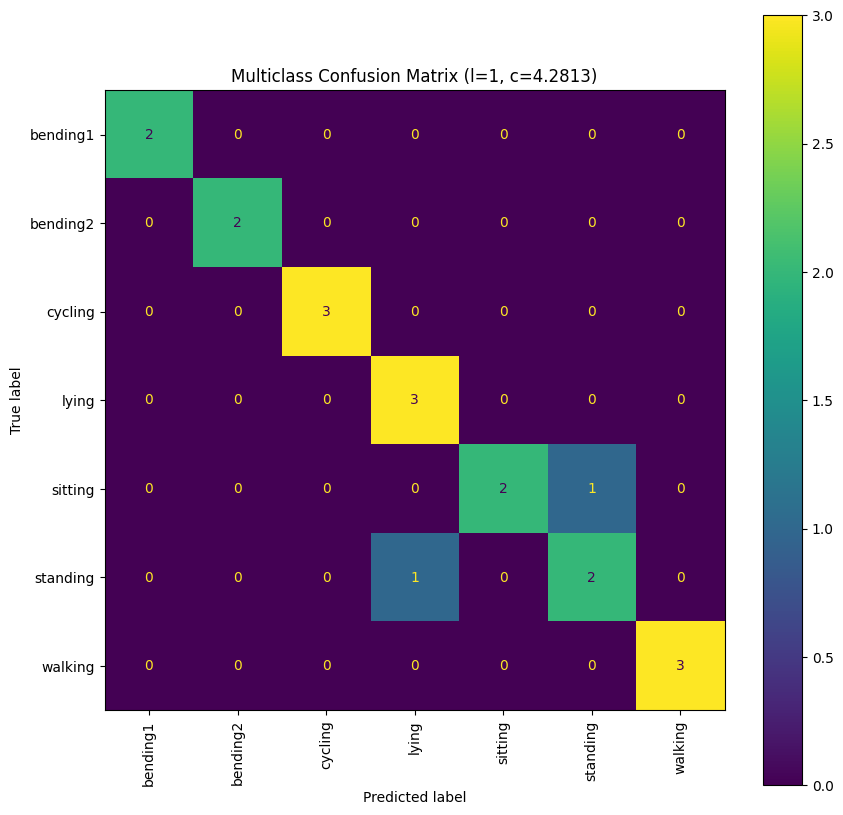

In [440]:
l_optimal_multi = 1
c_optimal_multi = 4.2813

X_train_final_multi = get_feature_matrix_for_l(X_train, l_optimal_multi)
scaler_final_multi = StandardScaler()
X_train_final_multi_scaled = scaler_final_multi.fit_transform(X_train_final_multi)

final_multi_model = LogisticRegression(
    C=c_optimal_multi,
    penalty='l1',
    solver='saga',
    multi_class='multinomial',
    max_iter=5000,
    random_state=11
)
final_multi_model.fit(X_train_final_multi_scaled, y_train)

X_test_final_multi = get_feature_matrix_for_l(X_test, l_optimal_multi)
X_test_final_multi_scaled = scaler_final_multi.transform(X_test_final_multi)

y_pred_test_multi = final_multi_model.predict(X_test_final_multi_scaled)
test_accuracy_multi = accuracy_score(y_test, y_pred_test_multi)
test_error_multi = 1 - test_accuracy_multi

class_names = list(label_map.keys()) 
cm_multi = confusion_matrix(y_test, y_pred_test_multi)
disp_multi = ConfusionMatrixDisplay(
    confusion_matrix=cm_multi, 
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(10, 10))
disp_multi.plot(ax=ax, xticks_rotation='vertical')
plt.title(f"Multiclass Confusion Matrix (l={l_optimal_multi}, c={c_optimal_multi})")
plt.show()

In [441]:
y_prob_test_multi = final_multi_model.predict_proba(X_test_final_multi_scaled)

auc_multi_ovr = roc_auc_score(
    y_test, 
    y_prob_test_multi, 
    multi_class='ovr',
    average='macro'         # macro-average: treats all classes equally
)
print(f"Macro-Averaged AUC Score: {auc_multi_ovr:.4f}")

auc_multi_ovr_weighted = roc_auc_score(
    y_test, 
    y_prob_test_multi, 
    multi_class='ovr',
    average='weighted'      # weighted-average: accounts for class imbalance
)
print(f"Weighted-Averaged AUC Score: {auc_multi_ovr_weighted:.4f}")

Macro-Averaged AUC Score: 0.9940
Weighted-Averaged AUC Score: 0.9934


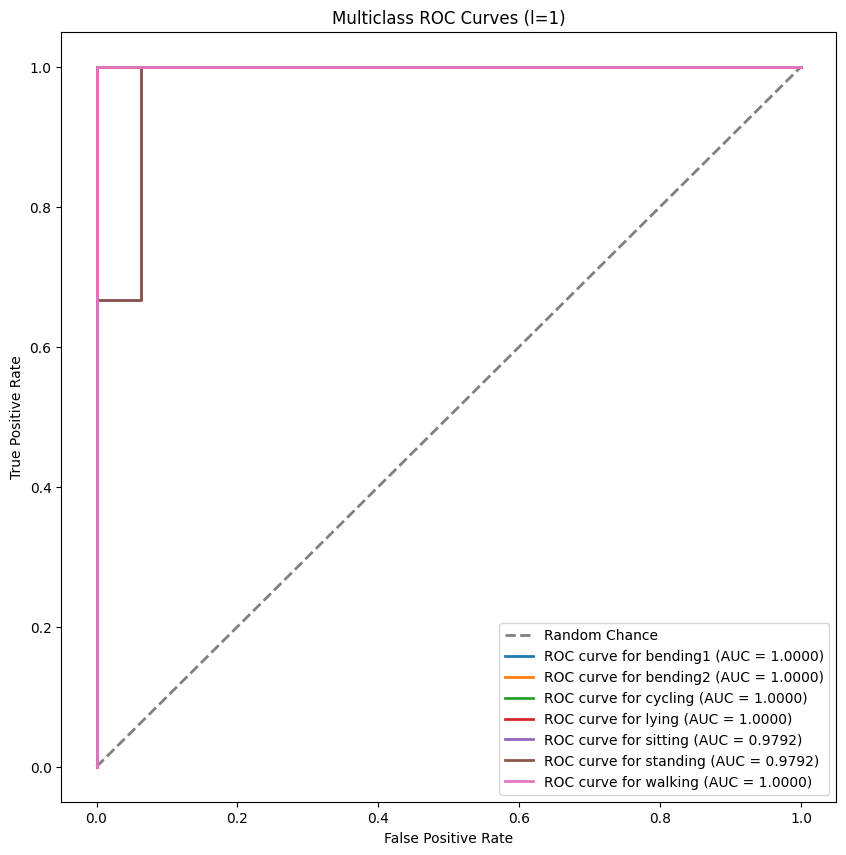

In [442]:
y_test_binarized = label_binarize(y_test, classes=list(label_map.values()))
n_classes = y_test_binarized.shape[1]

# Dictionaries to store the FPR and TPR for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # calculate ROC curve for class 'i' vs. all other classes
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob_test_multi[:, i])
    # claculate AUC for this class 'i'
    roc_auc[i] = roc_auc_score(y_test_binarized[:, i], y_prob_test_multi[:, i])

# --- Plot all ROC curves ---
plt.figure(figsize=(10, 10))

# Plot the "random chance" line
plt.plot([0, 1], [0, 1], 'k--', lw=2, color="gray", label='Random Chance')

# Plot each of the 7 ROC curves
for i in range(n_classes):
    plt.plot(
        fpr[i], 
        tpr[i], 
        lw=2, 
        label=f'ROC curve for {class_names[i]} (AUC = {roc_auc[i]:.4f})'
    )

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Multiclass ROC Curves (l={l_optimal_multi})')
plt.legend(loc="lower right")
plt.show()

In [443]:
print(f"--- Test Error Report ---")
print(f"The best model was trained with (l={l_optimal_multi}, C={c_optimal_multi:.4f})")
print(f"Test Accuracy: {test_accuracy_multi:.4f}")
print(f"Test Error (1 - Accuracy): {test_error_multi:.4f}")

--- Test Error Report ---
The best model was trained with (l=1, C=4.2813)
Test Accuracy: 0.8947
Test Error (1 - Accuracy): 0.1053


#### ii. Naive Bayes

- Step1: loop over l = 1,2,...20 to find optimal l
- Step2: use the optimal l to generate GaussianNB model and MultinomialNB model and train
- Step3: create optimal GaussianNB model and MultinomialNB model
- Step4: predict data using the optimal GaussianNB model and MultinomialNB model, compare the test error
- Step5: generate cm, ROC and AUC
- Step6: compare test error of optimal GaussianNB model and MultinomialNB model

In [444]:
results_gaussian = []
results_multinomial = []

for l in range(1, 21):
    X_L_train = get_feature_matrix_for_l(X_train, l)
    print(f"\n=== L = {l} ===")

    # --- GaussianNB ---
    scaler_gauss = StandardScaler()
    X_L_scaled_gauss = scaler_gauss.fit_transform(X_L_train)
    model_gauss = GaussianNB()
    scores_gauss = cross_val_score(model_gauss, X_L_scaled_gauss, y_train, cv=cv_strategy)
    acc_gauss = np.mean(scores_gauss)
    results_gaussian.append({'l': l, 'cv_accuracy': acc_gauss})

    # --- MultinomialNB ---
    # MultinomialNB cannot deal with negative values so we cannot use standardScaler here
    scaler_multi = MinMaxScaler() 
    X_L_scaled_multi = scaler_multi.fit_transform(X_L_train)
    model_multi = MultinomialNB()
    scores_multi = cross_val_score(model_multi, X_L_scaled_multi, y_train, cv=cv_strategy)
    acc_multi = np.mean(scores_multi)
    results_multinomial.append({'l': l, 'cv_accuracy': acc_multi})
    
    print(f"GaussianNB CV Acc: {acc_gauss:.4f} | MultinomialNB CV Acc: {acc_multi:.4f}")


=== L = 1 ===
GaussianNB CV Acc: 0.8407 | MultinomialNB CV Acc: 0.7110

=== L = 2 ===
GaussianNB CV Acc: 0.8275 | MultinomialNB CV Acc: 0.7549

=== L = 3 ===
GaussianNB CV Acc: 0.7385 | MultinomialNB CV Acc: 0.6813

=== L = 4 ===
GaussianNB CV Acc: 0.6253 | MultinomialNB CV Acc: 0.6945

=== L = 5 ===
GaussianNB CV Acc: 0.7231 | MultinomialNB CV Acc: 0.7396

=== L = 6 ===
GaussianNB CV Acc: 0.6692 | MultinomialNB CV Acc: 0.7110

=== L = 7 ===
GaussianNB CV Acc: 0.6692 | MultinomialNB CV Acc: 0.7242

=== L = 8 ===
GaussianNB CV Acc: 0.5648 | MultinomialNB CV Acc: 0.7099

=== L = 9 ===
GaussianNB CV Acc: 0.6242 | MultinomialNB CV Acc: 0.7242

=== L = 10 ===
GaussianNB CV Acc: 0.6967 | MultinomialNB CV Acc: 0.7099

=== L = 11 ===
GaussianNB CV Acc: 0.6385 | MultinomialNB CV Acc: 0.6956

=== L = 12 ===
GaussianNB CV Acc: 0.5813 | MultinomialNB CV Acc: 0.7099

=== L = 13 ===
GaussianNB CV Acc: 0.6681 | MultinomialNB CV Acc: 0.6956

=== L = 14 ===
GaussianNB CV Acc: 0.5813 | MultinomialNB CV

In [445]:
summary_df_gauss = pd.DataFrame(results_gaussian).sort_values(by='cv_accuracy', ascending=False)
summary_df_multinomial = pd.DataFrame(results_multinomial).sort_values(by='cv_accuracy', ascending=False)

l_best_g = summary_df_gauss.iloc[0]['l']
acc_best_g = summary_df_gauss.iloc[0]['cv_accuracy']

l_best_m = summary_df_multinomial.iloc[0]['l']
acc_best_m = summary_df_multinomial.iloc[0]['cv_accuracy']

print(f"Best GaussianNB: l={l_best_g} (CV Accuracy: {acc_best_g:.4f})")
print(f"Best MultinomialNB: l={l_best_m} (CV Accuracy: {acc_best_m:.4f})") # Use the same variable name here for clarity

Best GaussianNB: l=1.0 (CV Accuracy: 0.8407)
Best MultinomialNB: l=2.0 (CV Accuracy: 0.7549)


In [446]:
# train GaussianNB with optimal l
scaler_g_final = StandardScaler()
X_train_g_final = get_feature_matrix_for_l(X_train, l_best_g)
X_train_g_final_scaled = scaler_g_final.fit_transform(X_train_g_final)

final_model_g = GaussianNB()
final_model_g.fit(X_train_g_final_scaled, y_train)

# use GaussianNB model to predict on test data
X_test_g = get_feature_matrix_for_l(X_test, l_best_g)
X_test_g_scaled = scaler_g_final.transform(X_test_g)
y_pred_g = final_model_g.predict(X_test_g_scaled)
y_prob_g = final_model_g.predict_proba(X_test_g_scaled)

# train MultinomialNB with optimal l
scaler_m_final = MinMaxScaler()
X_train_m_final = get_feature_matrix_for_l(X_train, l_best_m)
X_train_m_final_scaled = scaler_m_final.fit_transform(X_train_m_final)

final_model_m = MultinomialNB()
final_model_m.fit(X_train_m_final_scaled, y_train)

# use MultinomialNB model to predict on test data
X_test_m = get_feature_matrix_for_l(X_test, l_best_m)
X_test_m_scaled = scaler_m_final.transform(X_test_m)
y_pred_m = final_model_m.predict(X_test_m_scaled)
y_prob_m = final_model_m.predict_proba(X_test_m_scaled)

# Compare test error
acc_g = accuracy_score(y_test, y_pred_g)
err_g = 1 - acc_g
acc_m = accuracy_score(y_test, y_pred_m)
err_m = 1 - acc_m

print("===Comparison of test error between optimal GaussianNB model and optimal MultinomialNB model===")
print(f"GaussianNB (l={l_best_g}):\tTest Accuracy = {acc_g:.4f}\tTest Error = {err_g:.4f}")
print(f"MultinomialNB (l={l_best_m}):\tTest Accuracy = {acc_m:.4f}\tTest Error = {err_m:.4f}")

===Comparison of test error between optimal GaussianNB model and optimal MultinomialNB model===
GaussianNB (l=1.0):	Test Accuracy = 0.8947	Test Error = 0.1053
MultinomialNB (l=2.0):	Test Accuracy = 0.7895	Test Error = 0.2105



--- GaussianNB Confusion Matrix (Test Set) ---


<Figure size 1000x1000 with 0 Axes>

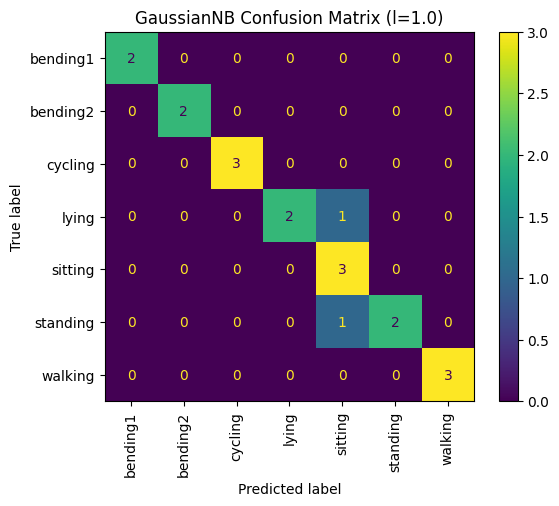


--- MultinomialNB Confusion Matrix (Test Set) ---


<Figure size 1000x1000 with 0 Axes>

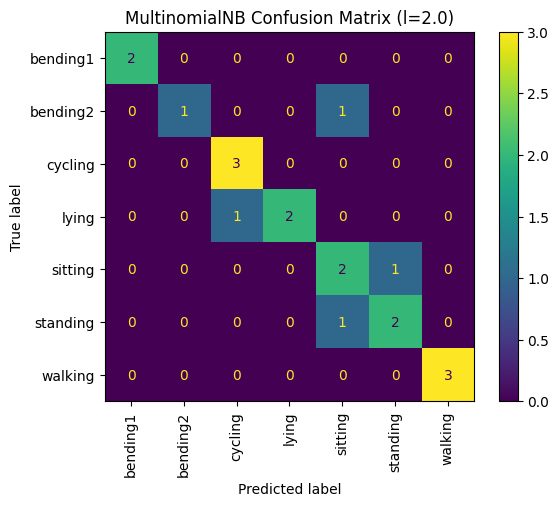

In [447]:
class_names = list(label_map.keys())

# --- GaussianNB CM ---
print("\n--- GaussianNB Confusion Matrix (Test Set) ---")
cm_g = confusion_matrix(y_test, y_pred_g)
disp_g = ConfusionMatrixDisplay(cm_g, display_labels=class_names)

plt.figure(figsize=(10, 10))
disp_g.plot(xticks_rotation='vertical')
plt.title(f"GaussianNB Confusion Matrix (l={l_best_g})")
plt.show()

# --- MultinomialNB CM ---
print("\n--- MultinomialNB Confusion Matrix (Test Set) ---")
cm_m = confusion_matrix(y_test, y_pred_m)
disp_m = ConfusionMatrixDisplay(cm_m, display_labels=class_names)

plt.figure(figsize=(10, 10))
disp_m.plot(xticks_rotation='vertical')
plt.title(f"MultinomialNB Confusion Matrix (l={l_best_m})")
plt.show()

In [448]:
y_test_binarized = label_binarize(y_test, classes=list(label_map.values()))
n_classes = y_test_binarized.shape[1]

auc_g_weighted = roc_auc_score(y_test, y_prob_g, multi_class='ovr', average='weighted')
auc_m_weighted = roc_auc_score(y_test, y_prob_m, multi_class='ovr', average='weighted')

print("\n--- Weighted-Average AUC (Test Set) ---")
print(f"GaussianNB AUC:   {auc_g_weighted:.4f}")
print(f"MultinomialNB AUC: {auc_m_weighted:.4f}")


--- Weighted-Average AUC (Test Set) ---
GaussianNB AUC:   0.9605
MultinomialNB AUC: 0.9638



--- GaussianNB OvR ROC Curves (Test Set) ---


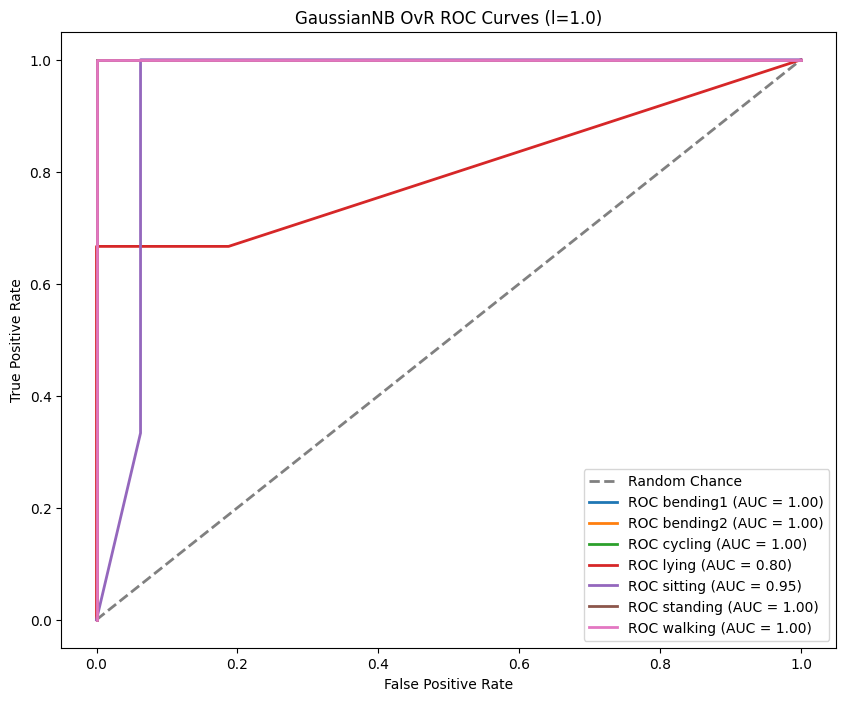


--- MultinomialNB OvR ROC Curves (Test Set) ---


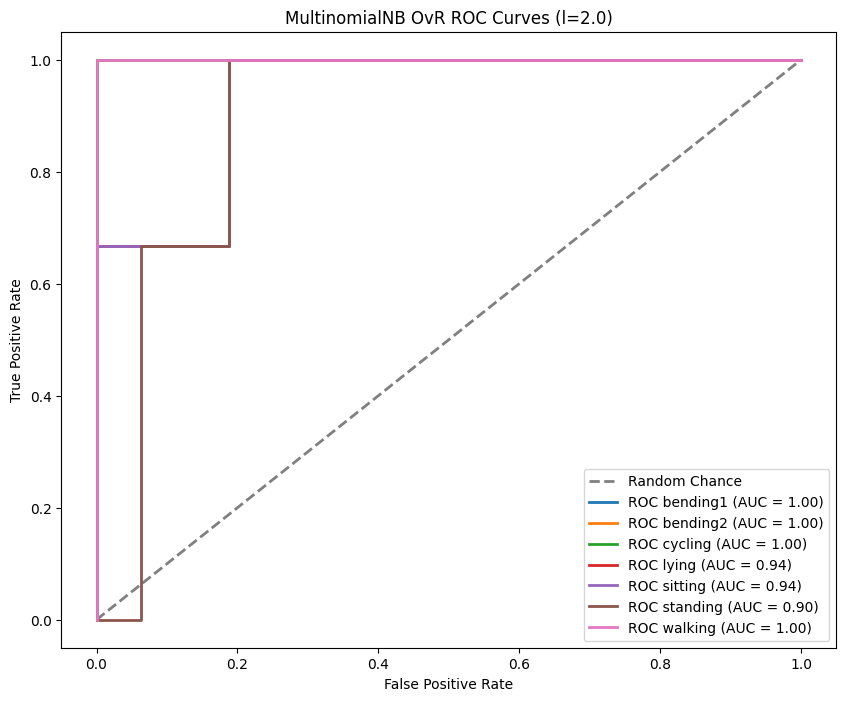

In [449]:
# --- GaussianNB ROC ---
print("\n--- GaussianNB OvR ROC Curves (Test Set) ---")
fpr_g = dict()
tpr_g = dict()
roc_auc_g = dict()

for i in range(n_classes):
    fpr_g[i], tpr_g[i], _ = roc_curve(y_test_binarized[:, i], y_prob_g[:, i])
    roc_auc_g[i] = roc_auc_score(y_test_binarized[:, i], y_prob_g[:, i])

# Plot all ROC curves for GaussianNB
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', lw=2, color="gray", label='Random Chance')
for i in range(n_classes):
    plt.plot(fpr_g[i], tpr_g[i], lw=2, label=f'ROC {class_names[i]} (AUC = {roc_auc_g[i]:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'GaussianNB OvR ROC Curves (l={l_best_g})')
plt.legend(loc="lower right")
plt.show()

# --- MultinomialNB ROC ---
print("\n--- MultinomialNB OvR ROC Curves (Test Set) ---")
fpr_m = dict()
tpr_m = dict()
roc_auc_m = dict()

for i in range(n_classes):
    fpr_m[i], tpr_m[i], _ = roc_curve(y_test_binarized[:, i], y_prob_m[:, i])
    roc_auc_m[i] = roc_auc_score(y_test_binarized[:, i], y_prob_m[:, i])

# Plot all ROC curves for MultinomialNB
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', lw=2, color='gray', label='Random Chance')
for i in range(n_classes):
    plt.plot(fpr_m[i], tpr_m[i], lw=2, label=f'ROC {class_names[i]} (AUC = {roc_auc_m[i]:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'MultinomialNB OvR ROC Curves (l={l_best_m})')
plt.legend(loc="lower right")
plt.show()

In terms of the performance on the test data, GaussianNB model performs better than MultinomialNB model because it has lower test error.

#### iii. Comparison

Summary of results of 3 models:

- L1 penalized model
    - optimal l = 1, c = 4.2813
    - test error = 0.1053
    - Weighted-Avg AUC = 0.9934
- Gaussian Naive Bayes Model
    - optimal l = 1
    - test error = 0.1053
    - Weighted-Avg AUC = 0.9605
- Multinomial Naive Bayes Model
    - optimal l = 2
    - test error = 0.2105
    - Weighted-Avg AUC = 0.9638

Based on the test error reported on the held-out test set, the L1-penalized logistic regression model and the Gaussian Naive Bayes Model have same test error and performs better than the Multinomial Model.

And the L1-penalized model has a higher weighted average AUC. This is aligned with what we can see from the RUC curves, most of the AUC = 1 in L1-penalized model. So in terms of seperate the data by different label, L1-penalized model performed better on more labels.

Hence, overall, L1-penalized model performed the best amoung three models.

## 3. ISLR 4.8.3

Want to show: the Bayes classifier is not linear but quadratic.

The discriminant function $\delta_k(x)$ is defined as:

$$
\delta_k(x) = \log(P(Y=k)) + \log(P(X=x | Y=k)) = \log(\pi_k) + \log(f_k(x))
$$

And since X follows normal distribution,

$$
f_k(x) = \frac{1}{\sqrt{2\pi}\sigma_k} \exp\left(-\frac{(x-\mu_k)^2}{2\sigma_k^2}\right)
$$

We can plug in $f_k(x)$ into the discriminant function and get:

$$
\delta_k(x) = \log(\pi_k) + \log\left(\frac{1}{\sqrt{2\pi}\sigma_k}\right) - \frac{(x-\mu_k)^2}{2\sigma_k^2}
$$

Now we expend the terms. Note that to only determine the function is linear or quadratic, we can ignore the constant terms of the function.

$$
\delta_k(x) = - \frac{x^2 - 2x\mu_k + \mu_k^2}{2\sigma_k^2} + \underbrace{\log(\pi_k) + \log\left(\frac{1}{\sqrt{2\pi}\sigma_k}\right)}_{\text{Constant w.r.t. } x}
$$

$$
= \left( -\frac{1}{2\sigma_k^2} \right) x^2 + \left( \frac{\mu_k}{\sigma_k^2} \right) x + \left( -\frac{\mu_k^2}{2\sigma_k^2} \right) + Constant
$$

Now we can see that $\delta_k(x)$ is a quadratic function of x where $-\frac{1}{2\sigma_k^2}$ is not zero.

## 4. ISLR 4.8.7

Bayes' theorem states:
$$P(Y | X=x) = \frac{P(X=x | Y) \cdot P(Y)}{P(X=x)}$$

Combine with the formula of the total probability:
$$f(x) = f(x | Y) \cdot P(Y) + f(x | N) \cdot P(N)$$

We have:
$$P(Y | X=x) = \frac{f_Y(x) \cdot P(Y)}{f_Y(x) \cdot P(Y) + f_N(x) \cdot P(N)}$$

Now given $P(Y)=0.80$, $P(N)=0.20$:

$$
\begin{aligned}
P(Y | X=4) &= \frac{f_Y(4) \cdot P(Y)}{f_Y(4) \cdot P(Y) + f_N(4) \cdot P(N)} \\
&= \frac{(\frac{1}{6\sqrt{2\pi}} e^{-0.5}) \cdot 0.80}{(\frac{1}{6\sqrt{2\pi}} e^{-0.5}) \cdot 0.80 + (\frac{1}{6\sqrt{2\pi}} e^{-2/9}) \cdot 0.20} \\
&= \frac{e^{-0.5} \cdot 0.80}{e^{-0.5} \cdot 0.80 + e^{-2/9} \cdot 0.20} \\
&\approx 0.7519
\end{aligned}
$$

### References:

1. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
2. https://scikit-learn.org/stable/modules/feature_selection.html
3. https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html
4. https://www.geeksforgeeks.org/machine-learning/stratified-k-fold-cross-validation/
5. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html
6. https://towardsdatascience.com/what-is-stratified-cross-validation-in-machine-learning-8844f3e7ae8e/
7. https://scikit-learn.org/stable/auto_examples/feature_selection/plot_rfe_with_cross_validation.html
8. https://numpy.org/doc/2.2/reference/generated/numpy.ravel.html
9. https://en.wikipedia.org/wiki/Limited-memory_BFGS
10. https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFECV.html
11. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
12. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html
13. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
14. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
15. https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.expit.html
16. https://ujangriswanto08.medium.com/step-by-step-guide-to-penalized-logistic-regression-in-python-9b21fe18a8b3
17. https://scikit-learn.org/stable/auto_examples/linear_model/plot_logistic_path.html
18. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html
19. https://medium.com/@arnavr/scikit-learn-solvers-explained-780a17bc322d
20. https://datascience.stackexchange.com/questions/65839/macro-average-and-weighted-average-meaning-in-classification-report
21. https://scikit-learn.org/stable/modules/naive_bayes.html
22. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
